# 🐟 ชุดข้อมูลการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย
**รหัสประจำตัว:** 607745 — ธวัช มหิทธิ (tawat.ma@gmail.com)

ชุดข้อมูลนี้แสดงข้อมูลการนำเข้าและส่งออกสินค้าประมงของประเทศไทย จำแนกตาม ประเทศคู่ค้า ประเภทสินค้า (HS Code) ปริมาณและน้ำหนักสินค้า มูลค่าการค้า เดือนและปีของการค้า

| Section | หัวข้อ |
|---|---|
| Section 1 | Setup & Load Data |
| Section 2 | Exploratory Data Analysis (EDA) |
| Section 3 | Data Quality & Cleaning |
| Section 4 | Advanced Analysis (Challenge Questions) |
| Section 5 | Key Insights Summary |


---
# Section 1 — Setup & Load Data 🚀

**วัตถุประสงค์:** ติดตั้ง Libraries, เชื่อมต่อ Google Drive และโหลดข้อมูลเข้าสู่ DataFrame

**ขั้นตอน:**
1. ติดตั้งและ Import Libraries ที่จำเป็น
2. ติดตั้ง Font ภาษาไทยสำหรับ Matplotlib
3. Mount Google Drive และโหลดไฟล์ CSV
4. ตรวจสอบโครงสร้างข้อมูลเบื้องต้น (shape, head, dtypes)
5. ตรวจสอบ Garbage Data เบื้องต้นก่อนเข้า EDA


### 1.1 ติดตั้ง Libraries
> ติดตั้ง pandas, numpy, matplotlib, seaborn, plotly และ Font ภาษาไทย (Sarabun) เพื่อให้แสดงผลภาษาไทยใน Chart ได้ถูกต้อง

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly --quiet
print("ติดตั้งเสร็จแล้วครบแล้ว")

ติดตั้งเสร็จแล้วครบแล้ว


### 1.2 Import Libraries & ตั้งค่า Font ภาษาไทย
> นำเข้า Library ทั้งหมด และตั้งค่า Sarabun Font เพื่อให้ Matplotlib แสดงภาษาไทยได้ ถ้าไม่ตั้งค่าจะเห็น □□□ แทนอักขระไทย
และ ทดสอบการใช้งานภาษาไทย

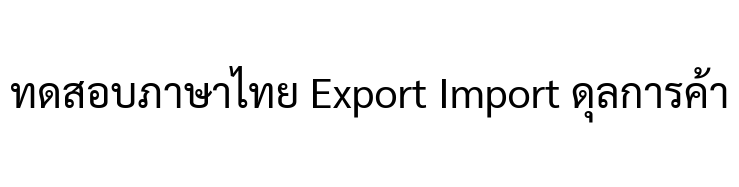

Font ภาษาไทยพร้อมใช้งานแล้ว!
Import Libraries สำเร็จ
   pandas  : 2.2.2
   numpy   : 2.0.2


In [ ]:
# Cell: ติดตั้ง Font ภาษาไทย (รันครั้งเดียวพอ)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── ดาวน์โหลด Font Sarabun (รองรับภาษาไทย) ──────────────
!wget -q "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf" -O /tmp/Sarabun-Regular.ttf
!wget -q "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Bold.ttf"    -O /tmp/Sarabun-Bold.ttf

# ── เพิ่ม Font เข้า Matplotlib ───────────────────────────
fm.fontManager.addfont('/tmp/Sarabun-Regular.ttf')
fm.fontManager.addfont('/tmp/Sarabun-Bold.ttf')

# ── ตั้งค่า Default Font ภาษาการใช้งาน ─────────────────────────────────
matplotlib.rc('font', family='Sarabun')
plt.rcParams['font.family']  = 'Sarabun'
plt.rcParams['axes.unicode_minus'] = False

# ── ทดสอบ ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 2))
ax.text(0.5, 0.5, 'ทดสอบภาษาไทย Export Import ดุลการค้า',
        ha='center', va='center', fontsize=30)
ax.axis('off')
plt.tight_layout()
plt.show()
print("Font ภาษาไทยพร้อมใช้งานแล้ว!")

# ติดตั้ง Library

import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ตั้งค่าหน้าตาการแสดงผล
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Import Libraries สำเร็จ")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

### 1.3 Mount Google Drive & โหลดข้อมูล
> เชื่อมต่อ Google Drive เพื่อเข้าถึงไฟล์ `import_export.csv` โดยตรง ไม่ต้องอัปโหลดซ้ำทุกครั้ง

In [ ]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')
print("เชื่อมต่อ Google Drive สำเร็จ!")

# โหลดไฟล์ CSV จาก Drive

import pandas as pd

# path ของไฟล์ใน Drive
FILE_PATH = '/content/drive/My Drive/Colab Notebooks/SuperAIS6/import_export.csv'

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')

print(f"โหลดข้อมูลสำเร็จ!")
print(f"   จำนวนแถว    : {df.shape[0]:,}")
print(f"   จำนวนคอลัมน์: {df.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
เชื่อมต่อ Google Drive สำเร็จ!
โหลดข้อมูลสำเร็จ!
   จำนวนแถว    : 42,057
   จำนวนคอลัมน์: 12


### 1.4 ตรวจสอบโครงสร้างข้อมูลเบื้องต้น
> ดู 5 แถวแรก, Data Types, และ Overview Summary เพื่อทำความเข้าใจข้อมูลก่อนวิเคราะห์

In [ ]:
# ดูตัวอย่างข้อมูล

print("5 แถวแรกของข้อมูล:")
df.head(5)

5 แถวแรกของข้อมูล:


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
0,2568,8,1062000002,BJ,เบนิน,33,90,48080,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
1,2568,8,1062000002,MU,มอริเชียส,10,50,44147,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
2,2568,8,1062000002,BR,บราซิล,8,150,47068,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
3,2568,8,1062000002,EG,อียิปต์,315,100,225663,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
4,2568,9,1062000002,KE,เคนยา,49,200,74954,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59


In [ ]:
# ตรวจสอบชนิดข้อมูลแต่ละคอลัมน์

print("ชนิดข้อมูล (Data Types):")
print("-" * 40)
for col in df.columns:
    print(f"  {col:<20} → {str(df[col].dtype):<10}  ({df[col].nunique()} unique values)")

ชนิดข้อมูล (Data Types):
----------------------------------------
  year                 → int64       (1 unique values)
  month                → int64       (12 unique values)
  heading11            → int64       (448 unique values)
  countryID            → object      (196 unique values)
  countryNameTH        → object      (197 unique values)
  weight               → int64       (17236 unique values)
  quantity             → int64       (17478 unique values)
  price                → int64       (37593 unique values)
  tradeflow            → int64       (2 unique values)
  productDetailEN      → object      (204 unique values)
  productDetailTH      → object      (431 unique values)
  ETL_DATE             → object      (1 unique values)


In [ ]:
# ภาพรวมข้อมูลทั้งหมด

print("=" * 50)
print("📊 Overview Summary")
print("=" * 50)

# ปี
print(f"\n📅 ปีในข้อมูล        : {sorted(df['year'].unique())}")
print(f"📅 เดือนที่มีข้อมูล   : {sorted(df['month'].unique())}")

# Tradeflow
tf_count = df['tradeflow'].value_counts()
print(f"\n📤 ส่งออก (Export=1) : {tf_count.get(1, 0):,} รายการ")
print(f"📥 นำเข้า (Import=2) : {tf_count.get(2, 0):,} รายการ")

# สินค้า / ประเทศ
print(f"\n🐟 จำนวนประเภทสินค้า  : {df['productDetailEN'].nunique():,} ประเภท")
print(f"🌏 จำนวนประเทศคู่ค้า  : {df['countryID'].nunique():,} ประเทศ")

# มูลค่ารวม (ก่อน clean)
print(f"\n💰 มูลค่ารวมทั้งหมด (ก่อน Clean):")
print(f"   ส่งออก : {df[df['tradeflow']==1]['price'].sum()/1e6:,.0f} ล้านบาท")
print(f"   นำเข้า : {df[df['tradeflow']==2]['price'].sum()/1e6:,.0f} ล้านบาท")

📊 Overview Summary

📅 ปีในข้อมูล        : [np.int64(2568)]
📅 เดือนที่มีข้อมูล   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

📤 ส่งออก (Export=1) : 13,238 รายการ
📥 นำเข้า (Import=2) : 28,819 รายการ

🐟 จำนวนประเภทสินค้า  : 204 ประเภท
🌏 จำนวนประเทศคู่ค้า  : 196 ประเทศ

💰 มูลค่ารวมทั้งหมด (ก่อน Clean):
   ส่งออก : 152,450 ล้านบาท
   นำเข้า : 223,123 ล้านบาท


### 1.5 ตรวจสอบ Garbage Data เบื้องต้น
> ตรวจหา Garbage ใน `productDetailEN` และค่า 0 ใน weight/quantity/price เพื่อตั้งสมมติฐานก่อนเข้า Section 3. เพราะว่าจากโจทย์ที่เราต้องการค่ามูลค่าการค้าเป็นหลัก

In [ ]:
# ตรวจสอบ Garbage ทุกประเภทใน productDetailEN

print("=" * 55)
print("🔍 ตรวจสอบ Garbage Data ใน productDetailEN")
print("=" * 55)

# ── ประเภท 1: ค่าที่รู้อยู่แล้ว ──────────────────────────
known_garbage = ['#NAME?', '(blank)', '']
print("\n📌 ประเภท 1 — ค่าพิเศษที่รู้อยู่แล้ว:")
for val in known_garbage:
    n = (df['productDetailEN'] == val).sum()
    print(f"   '{val}'  →  {n:,} แถว")

# ── ประเภท 2: ชื่อที่ขึ้นต้นด้วย dash/hyphen ────────────
print("\n📌 ประเภท 2 — ชื่อที่ขึ้นต้นด้วย - (dash):")
dash_mask = df['productDetailEN'].str.strip().str.startswith('-')
dash_rows = df[dash_mask]
print(f"   พบทั้งหมด: {len(dash_rows):,} แถว")
print(f"\n   ตัวอย่าง 10 ค่าแรก:")
for val in dash_rows['productDetailEN'].unique()[:10]:
    print(f"   → '{val}'")

# ── ประเภท 3: ชื่อที่สั้นผิดปกติ (< 3 ตัวอักษร) ─────────
print("\n📌 ประเภท 3 — ชื่อสั้นผิดปกติ (< 3 ตัวอักษร):")
short_mask = df['productDetailEN'].str.strip().str.len() < 3
short_rows = df[short_mask & ~df['productDetailEN'].isin(known_garbage)]
print(f"   พบทั้งหมด: {len(short_rows):,} แถว")
for val in short_rows['productDetailEN'].unique():
    print(f"   → '{val}'")

# ── สรุปรวม ──────────────────────────────────────────────
all_garbage_mask = (
    df['productDetailEN'].isin(known_garbage) |
    df['productDetailEN'].str.strip().str.startswith('-') |
    (df['productDetailEN'].str.strip().str.len() < 3)
)

total_garbage = all_garbage_mask.sum()
total_clean   = (~all_garbage_mask).sum()

print("\n" + "=" * 55)
print("📊 สรุปรวม Garbage ทุกประเภท:")
print(f"   ⚠️  Garbage รวม : {total_garbage:,} แถว  ({total_garbage/len(df)*100:.1f}%)")
print(f"   ✅  ข้อมูลดี   : {total_clean:,} แถว  ({total_clean/len(df)*100:.1f}%)")
print("=" * 55)

🔍 ตรวจสอบ Garbage Data ใน productDetailEN

📌 ประเภท 1 — ค่าพิเศษที่รู้อยู่แล้ว:
   '#NAME?'  →  7,586 แถว
   '(blank)'  →  8,689 แถว
   ''  →  0 แถว

📌 ประเภท 2 — ชื่อที่ขึ้นต้นด้วย - (dash):
   พบทั้งหมด: 921 แถว

   ตัวอย่าง 10 ค่าแรก:
   → '--Frogs' legs'
   → '- - Hake (Merluccius spp. Urophycis spp .)'
   → '- - Eels (Anguilla spp .)'
   → '- - - - Bluntnose lizardfish (Trachinocephalus'
   → '- - - - Savalai hairtails (Lepturacanthus savala )Belanger’s croakers (Johnius belangerii )Reeve’s croakers (Chrysochir aureus ) and bigeye croakers (Pennahia anea )'
   → '- - - - Torpedo scads (Megalaspis cordyla)barracudas (Sphyraena barracuda)'
   → '- - Other Pacific salmon (Oncorhynchus'
   → '- Tilapias (Oreochromis spp .)'
   → '- - Sardines (Sardina pilchardus  Sardinops spp .) sardinella (Sardinella spp. ) brisling or sprats (Sprattus sprattus )'
   → '- - Jack and horse mackerel (Trachurus spp .)'

📌 ประเภท 3 — ชื่อสั้นผิดปกติ (< 3 ตัวอักษร):
   พบทั้งหมด: 0 แถว

📊 สรุปรวม Garbage

In [ ]:
# ตรวจสอบค่า 0 ใน weight, quantity, price

print("=" * 55)
print("🔍 ตรวจสอบค่า 0 ใน weight / quantity / price")
print("=" * 55)

for col in ['weight', 'quantity', 'price']:
    zero_n   = (df[col] == 0).sum()
    zero_pct = zero_n / len(df) * 100
    print(f"\n📌 {col}:")
    print(f"   ค่า 0  : {zero_n:,} แถว ({zero_pct:.1f}%)")
    print(f"   min    : {df[col].min():,}")
    print(f"   max    : {df[col].max():,}")
    print(f"   mean   : {df[col].mean():,.1f}")

# ── ตรวจเคสที่ทั้ง 3 คอลัมน์เป็น 0 พร้อมกัน ──────────────
all_zero = df[(df['weight']==0) & (df['quantity']==0) & (df['price']==0)]
print(f"\n⚠️  แถวที่ weight=0 AND quantity=0 AND price=0:")
print(f"   พบ {len(all_zero):,} แถว → น่าจะเป็น Missing Data จริงๆ")

# ── ตรวจ weight=0 แต่ quantity > 0 (อาจปกติ เช่น สินค้าเบามาก) ──
w0_q_ok = df[(df['weight']==0) & (df['quantity']>0) & (df['price']>0)]
print(f"\n✅  weight=0 แต่ quantity>0 และ price>0:")
print(f"   พบ {len(w0_q_ok):,} แถว → อาจเป็นสินค้าที่ชั่งน้ำหนักไม่ได้")
print(f"   ตัวอย่างสินค้า:")
for p in w0_q_ok['productDetailEN'].unique()[:5]:
    print(f"   → {p}")

# 💡 สรุปหลักการ — จะเก็บหรือลบ?
# weight = 0  →  ⚠️ เก็บไว้ก่อน ถ้า quantity > 0 และ price > 0 (สินค้าบางชนิด เช่น สัตว์มีชีวิต วัดเป็นตัว ไม่ใช่น้ำหนัก)
# quantity = 0 →  ⚠️ เก็บไว้ก่อน ถ้า weight > 0 และ price > 0
# price = 0    →  ❌ ลบออก! ธุรกรรมที่ไม่มีมูลค่าไม่มีประโยชน์ในการวิเคราะห์

🔍 ตรวจสอบค่า 0 ใน weight / quantity / price

📌 weight:
   ค่า 0  : 463 แถว (1.1%)
   min    : 0
   max    : 18,684,570
   mean   : 88,774.1

📌 quantity:
   ค่า 0  : 102 แถว (0.2%)
   min    : 0
   max    : 2,375,725,750
   mean   : 317,965.3

📌 price:
   ค่า 0  : 12 แถว (0.0%)
   min    : 0
   max    : 1,157,585,877
   mean   : 8,930,085.7

⚠️  แถวที่ weight=0 AND quantity=0 AND price=0:
   พบ 1 แถว → น่าจะเป็น Missing Data จริงๆ

✅  weight=0 แต่ quantity>0 และ price>0:
   พบ 361 แถว → อาจเป็นสินค้าที่ชั่งน้ำหนักไม่ได้
   ตัวอย่างสินค้า:
   → Turtles and snapping turtles live
   → Taiwan snapping turtles
   → (blank)
   → #NAME?
   → Other live freshwater fish


---
# Section 2 — Exploratory Data Analysis (EDA) 🔍

**วัตถุประสงค์:** วิเคราะห์สถิติพื้นฐาน ตรวจสอบ Missing Values ความผิดปกติ และตั้งสมมติฐาน

**ขั้นตอน:**
1. วิเคราะห์สถิติพื้นฐาน (describe)
2. ตรวจสอบ Missing Values
3. ตรวจสอบค่า Unique และความผิดปกติระหว่างคอลัมน์
4. วิเคราะห์ Export vs Import Overview
5. วิเคราะห์รายเดือน, สินค้า, ประเทศ
6. ตั้งสมมติฐาน (Hypothesis) ทั้งหมด 11 ข้อ


### 2.1 สถิติพื้นฐาน (describe)
> `describe()` ให้ภาพรวม min/max/mean/std — ดูว่า max สูงกว่า mean มากแค่ไหน บ่งบอก Outlier ที่อาจมีผลต่อการวิเคราะห์

In [ ]:
# สถิติพื้นฐานของคอลัมน์ตัวเลข (describe)

print("=" * 55)
print("📊 สถิติพื้นฐาน (describe)")
print("=" * 55)

df[['weight', 'quantity', 'price']].describe().round(2)

📊 สถิติพื้นฐาน (describe)


,weight,quantity,price
count,"42,057.00","42,057.00","42,057.00"
mean,"88,774.08","317,965.26","8,930,085.71"
std,"452,321.56","12,684,767.33","40,824,843.30"
min,0.00,0.00,0.00
25%,87.00,215.00,"44,005.00"
50%,"2,700.00","3,390.00","554,101.00"
75%,"26,000.00","37,400.00","3,534,184.00"
max,"18,684,570.00","2,375,725,750.00","1,157,585,877.00"


### 2.2 ตรวจสอบ Missing Values
> ตรวจสอบว่ามีข้อมูลหายไปในคอลัมน์ใดบ้าง พร้อมดูแถวที่มีปัญหาเพื่อตัดสินใจ Clean ใน Section 3

In [ ]:
# ตรวจสอบค่าสูญหายทุกคอลัมน์

print("=" * 55)
print("🕳️  Missing Values Report")
print("=" * 55)

missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)

report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing (%)'   : pct,
    'Status'        : ['❌ มีปัญหา' if x > 0 else '✅ ปกติ' for x in missing]
})

print(report)
print(f"\nรวมแถวที่มี Missing อย่างน้อย 1 คอลัมน์: {df.isnull().any(axis=1).sum():,} แถว")

🕳️  Missing Values Report
                 Missing Count  Missing (%)     Status
year                         0         0.00     ✅ ปกติ
month                        0         0.00     ✅ ปกติ
heading11                    0         0.00     ✅ ปกติ
countryID                   25         0.06  ❌ มีปัญหา
countryNameTH                0         0.00     ✅ ปกติ
weight                       0         0.00     ✅ ปกติ
quantity                     0         0.00     ✅ ปกติ
price                        0         0.00     ✅ ปกติ
tradeflow                    0         0.00     ✅ ปกติ
productDetailEN              0         0.00     ✅ ปกติ
productDetailTH              0         0.00     ✅ ปกติ
ETL_DATE                     0         0.00     ✅ ปกติ

รวมแถวที่มี Missing อย่างน้อย 1 คอลัมน์: 25 แถว


In [ ]:
# ดูแถวที่มี Missing Values

print("=" * 55)
print("🕳️  แถวที่มี Missing Values")
print("=" * 55)

# ── หาแถวที่มี Missing ──────────────────────────────────
missing_rows = df[df.isnull().any(axis=1)].copy()

print(f"พบทั้งหมด : {len(missing_rows):,} แถว")
print(f"คิดเป็น   : {len(missing_rows)/len(df)*100:.2f}% ของข้อมูลทั้งหมด")

# ── ดูแบบตาราง (สะดวกกว่า) ─────────────────────────────
print("\n📋 ตารางแถวที่มี Missing (แสดงเฉพาะคอลัมน์สำคัญ):")

cols_show = ['year','month','countryID','countryNameTH',
             'productDetailEN','price','tradeflow']

missing_rows[cols_show]

🕳️  แถวที่มี Missing Values
พบทั้งหมด : 25 แถว
คิดเป็น   : 0.06% ของข้อมูลทั้งหมด

📋 ตารางแถวที่มี Missing (แสดงเฉพาะคอลัมน์สำคัญ):


,year,month,countryID,countryNameTH,productDetailEN,price,tradeflow
5580,2568,3,NaN,นามิเบีย,Albacore or longfinned tunas(Thunnus alalunga) excluding livers and roes frozen,16318673,1
6118,2568,7,NaN,นามิเบีย,Yellowfin tunas(Thunnus albacares) excluding livers and roes frozen,650647,1
6956,2568,12,NaN,นามิเบีย,Bigeyes tunas(Thunnus obesus) excluding livers and roes frozen,382881,1
6991,2568,7,NaN,นามิเบีย,Bigeyes tunas(Thunnus obesus) excluding livers and roes frozen,10206334,1
8366,2568,10,NaN,นามิเบีย,Shark fins,859142,1
8380,2568,7,NaN,นามิเบีย,Shark fins,1468115,1
8546,2568,7,NaN,นามิเบีย,Other,863597,1
20189,2568,1,NaN,นามิเบีย,Sardines sardinella and brisling or sprats prepared or preserved in airtight...,7914733,2
20223,2568,2,NaN,นามิเบีย,Sardines sardinella and brisling or sprats prepared or preserved in airtight...,31135949,2
20251,2568,3,NaN,นามิเบีย,Sardines sardinella and brisling or sprats prepared or preserved in airtight...,11639781,2


### 2.3 ตรวจสอบ Unique Values และความผิดปกติ
> `countryID(196) ≠ countryNameTH(197)` และ `productDetailEN(204) ≠ productDetailTH(431)` บ่งชี้ปัญหาในข้อมูลที่ต้องแก้ไข

In [ ]:
# นับค่า Unique แต่ละคอลัมน์

print("=" * 55)
print("🔢  Unique Values ต่อคอลัมน์")
print("=" * 55)

for col in df.columns:
    n = df[col].nunique()
    print(f"  {col:<22} → {n:>6,} unique values")

🔢  Unique Values ต่อคอลัมน์
  year                   →      1 unique values
  month                  →     12 unique values
  heading11              →    448 unique values
  countryID              →    196 unique values
  countryNameTH          →    197 unique values
  weight                 → 17,236 unique values
  quantity               → 17,478 unique values
  price                  → 37,593 unique values
  tradeflow              →      2 unique values
  productDetailEN        →    204 unique values
  productDetailTH        →    431 unique values
  ETL_DATE               →      1 unique values


In [ ]:
# ปัญหาที่ 1: countryID vs countryNameTH ไม่เท่ากัน ───
print("=" * 55)
print("❓ ปัญหาที่ 1: countryID(196) ≠ countryNameTH(197)")
print("=" * 55)

# หา countryNameTH ที่ไม่มี countryID (น่าจะเป็น 1 ค่า)
no_id = df[df['countryID'].isnull()]['countryNameTH'].unique()
print(f"\n🔍 countryNameTH ที่ไม่มี countryID ({len(no_id)} ค่า):")
for v in no_id:
    n = (df['countryNameTH'] == v).sum()
    print(f"   → '{v}'  ({n} แถว)")

# หา countryID ที่มีชื่อ TH มากกว่า 1 ชื่อ (อาจพิมพ์ผิด)
print(f"\n🔍 countryID ที่มีชื่อภาษาไทยมากกว่า 1 แบบ:")
dup_name = (df.groupby('countryID')['countryNameTH']
              .nunique()
              .reset_index()
              .query('countryNameTH > 1'))
if len(dup_name) > 0:
    for _, row in dup_name.iterrows():
        names = df[df['countryID']==row['countryID']]['countryNameTH'].unique()
        print(f"   → {row['countryID']} : {list(names)}")
else:
    print("   ✅ ไม่พบ")

❓ ปัญหาที่ 1: countryID(196) ≠ countryNameTH(197)

🔍 countryNameTH ที่ไม่มี countryID (1 ค่า):
   → 'นามิเบีย'  (25 แถว)

🔍 countryID ที่มีชื่อภาษาไทยมากกว่า 1 แบบ:
   ✅ ไม่พบ


In [ ]:
# ปัญหาที่ 2: productDetailEN(204) ≠ productDetailTH(431) ─
print("\n" + "=" * 55)
print("❓ ปัญหาที่ 2: productDetailEN(204) ≠ productDetailTH(431)")
print("=" * 55)

# EN 1 ตัว → TH หลายตัว?
en_to_th = (df.groupby('productDetailEN')['productDetailTH']
              .nunique()
              .sort_values(ascending=False)
              .reset_index()
              .rename(columns={'productDetailTH':'จำนวนชื่อ TH'}))

print(f"\n🔍 productDetailEN ที่มีชื่อ TH มากกว่า 1 แบบ:")
many_th = en_to_th[en_to_th['จำนวนชื่อ TH'] > 1]
print(f"   พบ {len(many_th)} สินค้า\n")
print(many_th.head(10).to_string(index=False))

# ดูตัวอย่าง
if len(many_th) > 0:
    sample_en = many_th.iloc[0]['productDetailEN']
    print(f"\n📌 ตัวอย่าง: '{sample_en[:50]}'")
    print("   มีชื่อ TH ดังนี้:")
    for th in df[df['productDetailEN']==sample_en]['productDetailTH'].unique():
        print(f"   → '{th}'")


❓ ปัญหาที่ 2: productDetailEN(204) ≠ productDetailTH(431)

🔍 productDetailEN ที่มีชื่อ TH มากกว่า 1 แบบ:
   พบ 16 สินค้า

                         productDetailEN  จำนวนชื่อ TH
                                  #NAME?            82
                                 (blank)            80
                                   Other            49
                              Other fish             6
                Dried salted or in brine             4
                         Other fish meat             3
Cooked bysteaming or by boiling in water             3
               - - Eels (Anguilla spp .)             2
                                  Frozen             2
                               Crocodile             2

📌 ตัวอย่าง: '#NAME?'
   มีชื่อ TH ดังนี้:
   → 'ปลาคาร์ป สวยงามมีชีวิต (แฟนซีคาร์ป) (ไซพรีนสคาร์ปิโอ)'
   → 'ปลาทองสวยงามมีชีวิต (คารัสเซียสออราทัส)'
   → 'ปลากัดไทยสวยงามมีชีวิต (เบตาสเพลนเดนส์)'
   → 'ปลาอะโรวานาสวยงามมีชีวิต (สเคอโรพากีสฟอรโมซัส)'
   → 'ลูกปลาอื่นๆสวย

### 2.4 Export vs Import Overview
> เปรียบเทียบจำนวนรายการและมูลค่ารวม ระหว่าง Export (tradeflow=2) และ Import (tradeflow=1) เพื่อดูดุลการค้าเบื้องต้น

In [ ]:
# เปรียบเทียบ Export vs Import
# *** จาก Data Dictionary: tradeflow 1=Import, 2=Export ***

print("=" * 55)
print("📤📥  Export vs Import Overview")
print("=" * 55)

for tf, label in [(1, 'Import (นำเข้า)'), (2, 'Export (ส่งออก)')]:
    sub = df[df['tradeflow'] == tf]
    print(f"\n🔹 {label}")
    print(f"   จำนวนรายการ : {len(sub):,}")
    print(f"   มูลค่ารวม   : {sub['price'].sum():,}  บาท×1M")
    print(f"   น้ำหนักรวม  : {sub['weight'].sum():,}  กก.×1K")
    print(f"   จำนวนสินค้า : {sub['productDetailEN'].nunique():,} ประเภท")
    print(f"   จำนวนประเทศ : {sub['countryID'].nunique():,} ประเทศ")

# ดุลการค้า
exp_val = df[df['tradeflow']==2]['price'].sum()
imp_val = df[df['tradeflow']==1]['price'].sum()
bal     = exp_val - imp_val
print(f"\n⚖️  ดุลการค้า (Export - Import) : {bal:,}")
print(f"   {'✅ เกินดุล' if bal > 0 else '❌ ขาดดุล'}")

📤📥  Export vs Import Overview

🔹 Import (นำเข้า)
   จำนวนรายการ : 13,238
   มูลค่ารวม   : 152,449,613,596  บาท×1M
   น้ำหนักรวม  : 2,062,887,216  กก.×1K
   จำนวนสินค้า : 163 ประเภท
   จำนวนประเทศ : 124 ประเทศ

🔹 Export (ส่งออก)
   จำนวนรายการ : 28,819
   มูลค่ารวม   : 223,123,001,243  บาท×1M
   น้ำหนักรวม  : 1,670,684,465  กก.×1K
   จำนวนสินค้า : 169 ประเภท
   จำนวนประเทศ : 187 ประเทศ

⚖️  ดุลการค้า (Export - Import) : 70,673,387,647
   ✅ เกินดุล


### 2.5 วิเคราะห์รายเดือน สินค้า และประเทศ
> วิเคราะห์ Pattern รายเดือน Top 10 สินค้า และ Top 10 ประเทศ เพื่อหา Pattern และ Trend เบื้องต้น

In [ ]:
# Cell 5: จำนวนรายการและมูลค่ารายเดือน (แก้ไขแล้ว)

month_map = {
    1:'ม.ค.', 2:'ก.พ.', 3:'มี.ค.', 4:'เม.ย.',
    5:'พ.ค.', 6:'มิ.ย.', 7:'ก.ค.', 8:'ส.ค.',
    9:'ก.ย.', 10:'ต.ค.', 11:'พ.ย.', 12:'ธ.ค.'
}

monthly = (df.groupby('month')
             .agg(count=('price', 'count'),
                  total_value=('price', 'sum'))
             .rename(index=month_map))

print("=" * 45)
print("📅  ข้อมูลรายเดือน")
print("=" * 45)
print(monthly.to_string())
print(f"\n👉 เดือนที่มีรายการมากสุด  : {monthly['count'].idxmax()}")
print(f"👉 เดือนที่มีมูลค่าสูงสุด  : {monthly['total_value'].idxmax()}")

📅  ข้อมูลรายเดือน
       count  total_value
month                    
ม.ค.    3519  33111051180
ก.พ.    3488  29872254038
มี.ค.   3520  32186645667
เม.ย.   3459  29652487049
พ.ค.    3652  33292609686
มิ.ย.   3538  29527767813
ก.ค.    3472  29432627513
ส.ค.    3519  28319142438
ก.ย.    3519  30985119837
ต.ค.    3514  33419173946
พ.ย.    3354  32665701416
ธ.ค.    3503  33108034256

👉 เดือนที่มีรายการมากสุด  : พ.ค.
👉 เดือนที่มีมูลค่าสูงสุด  : ต.ค.


In [ ]:
# Top 10 สินค้า แยก Export / Import

for tf, label, emoji in [(2,'Export (ส่งออก)','📤'), (1,'Import (นำเข้า)','📥')]:
    print(f"\n{emoji}  Top 10 สินค้า — {label}")
    print("-" * 55)
    top = (df[df['tradeflow']==tf]
           .groupby('productDetailEN')['price']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())
    top.index += 1
    top['productDetailEN'] = top['productDetailEN'].str[:50]
    top.columns = ['สินค้า','มูลค่า (บาท×1M)']
    print(top.to_string())


📤  Top 10 สินค้า — Export (ส่งออก)
-------------------------------------------------------
                                                สินค้า  มูลค่า (บาท×1M)
1                                               #NAME?      81307140097
2                                              (blank)      41465754773
3                                                Other      30655762393
4   White shrimp(P.vannamei) not in airtight container       8206304934
5                                         Squid frozen       6147090580
6                                          Surimi meat       5070870234
7                                       Breaded shrimp       4991734258
8      White shrimp(P.vannamei) in airtight containers       4316082684
9   Sardines sardinella and brisling or sprats prepare       3609832267
10            Cooked bysteaming or by boiling in water       3550670065

📥  Top 10 สินค้า — Import (นำเข้า)
-------------------------------------------------------
                        

In [ ]:
# Top 10 ประเทศ Import & Export พร้อมมูลค่า

total_imp = df[df['tradeflow'] == 1]['price'].sum()
total_exp = df[df['tradeflow'] == 2]['price'].sum()

# ── TOP 10 IMPORT ─────────────────────────────────────────
top10_imp = (df[df['tradeflow'] == 1]
             .groupby(['countryID', 'countryNameTH'])['price']
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .reset_index())

print("=" * 65)
print("📥  Top 10 ประเทศที่ไทย นำเข้า (Import)")
print("=" * 65)
print(f"  {'#':<3} {'รหัส':<5} {'ชื่อประเทศ':<20} {'มูลค่า (ล้านบาท)':>18} {'สัดส่วน':>8}")
print("-" * 65)
for i, row in top10_imp.iterrows():
    val_m = row['price'] / 1e6
    pct   = row['price'] / total_imp * 100
    print(f"  {i+1:<3} {row['countryID']:<5} {row['countryNameTH']:<20} {val_m:>18,.1f} {pct:>7.1f}%")

print("-" * 65)
print(f"  {'รวม Top 10':<26} {top10_imp['price'].sum()/1e6:>18,.1f} "
      f"{top10_imp['price'].sum()/total_imp*100:>7.1f}%")
print(f"  {'รวมทั้งหมด':<26} {total_imp/1e6:>18,.1f} {'100.0%':>8}")

# ── TOP 10 EXPORT ─────────────────────────────────────────
top10_exp = (df[df['tradeflow'] == 2]
             .groupby(['countryID', 'countryNameTH'])['price']
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .reset_index())

print("\n" + "=" * 65)
print("📤  Top 10 ประเทศที่ไทย ส่งออก (Export)")
print("=" * 65)
print(f"  {'#':<3} {'รหัส':<5} {'ชื่อประเทศ':<20} {'มูลค่า (ล้านบาท)':>18} {'สัดส่วน':>8}")
print("-" * 65)
for i, row in top10_exp.iterrows():
    val_m = row['price'] / 1e6
    pct   = row['price'] / total_exp * 100
    print(f"  {i+1:<3} {row['countryID']:<5} {row['countryNameTH']:<20} {val_m:>18,.1f} {pct:>7.1f}%")

print("-" * 65)
print(f"  {'รวม Top 10':<26} {top10_exp['price'].sum()/1e6:>18,.1f} "
      f"{top10_exp['price'].sum()/total_exp*100:>7.1f}%")
print(f"  {'รวมทั้งหมด':<26} {total_exp/1e6:>18,.1f} {'100.0%':>8}")

📥  Top 10 ประเทศที่ไทย นำเข้า (Import)
  #   รหัส  ชื่อประเทศ             มูลค่า (ล้านบาท)  สัดส่วน
-----------------------------------------------------------------
  1   CN    จีน                            19,858.1    13.0%
  2   NO    นอร์เวย์                       13,563.6     8.9%
  3   IN    อินเดีย                        11,726.8     7.7%
  4   VN    เวียดนาม                       11,081.2     7.3%
  5   TW    ไต้หวัน                         9,058.5     5.9%
  6   JP    ญี่ปุ่น                         8,626.0     5.7%
  7   ID    อินโดนีเซีย                     7,885.9     5.2%
  8   KR    เกาหลีใต้                       6,782.6     4.4%
  9   US    สหรัฐอเมริกา                    5,508.1     3.6%
  10  CL    ชิลี                            4,531.8     3.0%
-----------------------------------------------------------------
  รวม Top 10                           98,622.5    64.7%
  รวมทั้งหมด                          152,449.6   100.0%

📤  Top 10 ประเทศที่ไทย ส่งออก (Export)
  # 

### 2.6 ตั้งสมมติฐาน (Hypothesis) จาก EDA
> รวบรวมสมมติฐานแบ่งเป็น Data Quality, Trade Balance, Product, Country และ Limitation — จะพิสูจน์ทุกข้อใน Section 3 และ 4

In [ ]:
# สรุปสมมติฐานจากสิ่งที่พบใน Section 2 ทั้งหมด

print("=" * 65)
print("💡  สมมติฐาน (Hypothesis) จาก EDA — Section 2")
print("    จะพิสูจน์ใน Section 4 — Advanced EDA")
print("=" * 65)

hypotheses = [

    # ── Data Quality ──────────────────────────────────────
    ("DQ-1", "🗑️  Garbage ใน productDetailEN สูงมาก",
     "พบ #NAME?, (blank), และชื่อขึ้นต้นด้วย -\n"
     "     คาดว่ามีผลกระทบ ~38% ของข้อมูลทั้งหมด\n"
     "     → ต้องลบออกก่อนวิเคราะห์ทุกครั้ง"),

    ("DQ-2", "🌏  countryID น้อยกว่า countryNameTH อยู่ 1 ค่า",
     "มีประเทศที่มีชื่อภาษาไทย แต่ไม่มีรหัส ISO\n"
     "     → น่าจะเป็นประเทศ/ดินแดนที่ไม่มีรหัสมาตรฐาน\n"
     "     → ควรลบหรือเติมรหัสเอง"),

    ("DQ-3", "🐟  productDetailEN(204) น้อยกว่า productDetailTH(431)",
     "ชื่อสินค้าภาษาไทยพิมพ์ไม่สม่ำเสมอ 1 EN → หลาย TH\n"
     "     → ควรใช้ productDetailEN เป็น Key หลักในการวิเคราะห์"),

    ("DQ-4", "💰  price = 0 ควรตัดออก",
     "ธุรกรรมที่ไม่มีมูลค่าไม่มีนัยสำคัญในการวิเคราะห์\n"
     "     → weight=0 หรือ quantity=0 ยังเก็บได้ถ้า price > 0"),

    # ── Trade Balance ─────────────────────────────────────
    ("TB-1", "⚖️  ไทยน่าจะเกินดุลการค้าประมง",
     "Export(tradeflow=2) > Import(tradeflow=1) เบื้องต้น\n"
     "     → ต้องยืนยันอีกครั้งหลัง Data Cleaning"),

    ("TB-2", "📅  มกราคมมีมูลค่าการค้าสูงสุด",
     "รายการเดือน ม.ค. สูงที่สุดทั้ง Import และ Export\n"
     "     → อาจเป็นผลจากการเร่งส่งสินค้าต้นปี\n"
     "     → หรือ Backlog จากปลายปีก่อน"),

    # ── Product ───────────────────────────────────────────
    ("PR-1", "🐟  Top 5 สินค้าส่งออกคิดเป็น > 50% ของมูลค่ารวม",
     "ปลาทูน่า ปลาโอ หมึก น่าจะครองสัดส่วนสูง\n"
     "     → สะท้อนความเชี่ยวชาญของอุตสาหกรรมประมงไทย"),

    ("PR-2", "🦐  กุ้ง Vannamei ครองตลาด Import",
     "โรงงานแปรรูปกุ้งในไทยต้องพึ่งพาวัตถุดิบจากต่างประเทศ\n"
     "     → White shrimp น่าจะติด Top 3 สินค้านำเข้า"),

    # ── Country ───────────────────────────────────────────
    ("CT-1", "🌏  ตลาด Export กระจายตัวดีกว่า Import",
     "Export ไป 180+ ประเทศ แต่ Import กระจุกตัวน้อยกว่า\n"
     "     → Top 5 Import น่าจะคิดเป็น > 60% ของมูลค่านำเข้า"),

    ("CT-2", "🇨🇳  จีนน่าจะติด Top 3 ทั้ง Import และ Export",
     "จีนเป็นคู่ค้าหลักของไทยในหลายอุตสาหกรรม\n"
     "     → น่าจะเป็นทั้งแหล่งนำเข้าและตลาดส่งออกสำคัญ"),

    # ── Data Limitation ───────────────────────────────────
    ("LM-1", "📆  มีข้อมูลเพียงปีเดียว (2568) เท่านั้น",
     "ไม่สามารถวิเคราะห์ YoY Trend ได้\n"
     "     → วิเคราะห์ได้เฉพาะ Seasonal Pattern ภายในปีเดียวกัน"),

]

for code, title, detail in hypotheses:
    print(f"\n  [{code}]  {title}")
    print(f"     → {detail}")

print("\n" + "=" * 65)
print(f"  รวมทั้งหมด {len(hypotheses)} สมมติฐาน")
print("  แบ่งเป็น:")
print("    🗑️  Data Quality    : DQ-1 ถึง DQ-4  (4 ข้อ)")
print("    ⚖️  Trade Balance   : TB-1 ถึง TB-2  (2 ข้อ)")
print("    🐟  Product         : PR-1 ถึง PR-2  (2 ข้อ)")
print("    🌏  Country         : CT-1 ถึง CT-2  (2 ข้อ)")
print("    📆  Data Limitation : LM-1            (1 ข้อ)")
print("=" * 65)

💡  สมมติฐาน (Hypothesis) จาก EDA — Section 2
    จะพิสูจน์ใน Section 4 — Advanced EDA

  [DQ-1]  🗑️  Garbage ใน productDetailEN สูงมาก
     → พบ #NAME?, (blank), และชื่อขึ้นต้นด้วย -
     คาดว่ามีผลกระทบ ~38% ของข้อมูลทั้งหมด
     → ต้องลบออกก่อนวิเคราะห์ทุกครั้ง

  [DQ-2]  🌏  countryID น้อยกว่า countryNameTH อยู่ 1 ค่า
     → มีประเทศที่มีชื่อภาษาไทย แต่ไม่มีรหัส ISO
     → น่าจะเป็นประเทศ/ดินแดนที่ไม่มีรหัสมาตรฐาน
     → ควรลบหรือเติมรหัสเอง

  [DQ-3]  🐟  productDetailEN(204) น้อยกว่า productDetailTH(431)
     → ชื่อสินค้าภาษาไทยพิมพ์ไม่สม่ำเสมอ 1 EN → หลาย TH
     → ควรใช้ productDetailEN เป็น Key หลักในการวิเคราะห์

  [DQ-4]  💰  price = 0 ควรตัดออก
     → ธุรกรรมที่ไม่มีมูลค่าไม่มีนัยสำคัญในการวิเคราะห์
     → weight=0 หรือ quantity=0 ยังเก็บได้ถ้า price > 0

  [TB-1]  ⚖️  ไทยน่าจะเกินดุลการค้าประมง
     → Export(tradeflow=2) > Import(tradeflow=1) เบื้องต้น
     → ต้องยืนยันอีกครั้งหลัง Data Cleaning

  [TB-2]  📅  มกราคมมีมูลค่าการค้าสูงสุด
     → รายการเดือน ม.ค. สูงที่สุดทั้ง Imp

---
# Section 3 — Data Quality & Cleaning 🧹

**วัตถุประสงค์:** ทำความสะอาดข้อมูลให้พร้อมวิเคราะห์ โดยไม่ลบข้อมูลโดยไม่เข้าใจสาเหตุก่อน

**หลักการสำคัญ:** "อย่าลบก่อนเข้าใจ" — วิเคราะห์สาเหตุ Garbage แต่ละประเภทก่อนตัดสินใจ

**ขั้นตอน:**
1. สำรองข้อมูลต้นฉบับ (df_raw)
2. วิเคราะห์สาเหตุ Garbage ใน productDetailEN
3. ตรวจสอบ productDetailTH
4. ลบ productDetailEN (ใช้ TH เป็นหลัก)
5. แก้ countryID ของ นามิเบีย (NA ถูกอ่านเป็น NaN)
6. เพิ่มคอลัมน์ Quarter, Season, trade_label
7. แปลง tradeflow เป็น Text
8. Final Quality Check


### 3.1 สำรองข้อมูลต้นฉบับ
> ทำสำเนา `df_raw` ไว้เสมอก่อน Clean — ถ้า Clean ผิดพลาดสามารถเริ่มใหม่ได้จาก `df_raw` โดยไม่ต้องโหลดไฟล์ใหม่

In [ ]:
# สำรองข้อมูลต้นฉบับไว้เสมอ ก่อน Clean

df_raw = df.copy()  # เก็บต้นฉบับไว้

print("✅ สำรองข้อมูลต้นฉบับแล้ว")
print(f"   df_raw : {df_raw.shape[0]:,} แถว  (ต้นฉบับ ห้ามแก้ไข!)")
print(f"   df     : {df.shape[0]:,} แถว  (จะ Clean ต่อไป)")

✅ สำรองข้อมูลต้นฉบับแล้ว
   df_raw : 42,057 แถว  (ต้นฉบับ ห้ามแก้ไข!)
   df     : 42,057 แถว  (จะ Clean ต่อไป)


### 3.2 วิเคราะห์สาเหตุ Garbage ใน productDetailEN
> Garbage มี 3 ประเภท: `#NAME?` (Excel formula error), `(blank)` (Pivot Table), `---` (HS Sub-level) แต่ละประเภทกู้คืนได้ต่างกัน

In [ ]:
# ศึกษาเข้าใจ Garbage ก่อน — อย่าเพิ่งลบ!

print("=" * 60)
print("🔬  วิเคราะห์สาเหตุ Garbage ใน productDetailEN")
print("=" * 60)

# ── ประเภทที่ 1: #NAME? ───────────────────────────────────
print("\n📌 ประเภทที่ 1 : '#NAME?'")
name_err = df[df['productDetailEN'] == '#NAME?']
print(f"   พบ : {len(name_err):,} แถว")
print(f"   สาเหตุที่เป็นไปได้:")
print(f"   → Excel อ่านค่าในเซลล์ผิดพลาด (cell เริ่มด้วย = หรือ @)")
print(f"   → ETL Export จาก Excel โดยไม่ได้แปลง formula เป็น value")
print(f"\n   ตรวจสอบ productDetailTH คู่กัน:")
for th, n in name_err['productDetailTH'].value_counts().head(5).items():
    print(f"   → TH: '{th}'  ({n} แถว)")
print(f"\n   💡 ชื่อภาษาไทยยังอยู่ครบ → สามารถกู้คืนได้!")

🔬  วิเคราะห์สาเหตุ Garbage ใน productDetailEN

📌 ประเภทที่ 1 : '#NAME?'
   พบ : 7,586 แถว
   สาเหตุที่เป็นไปได้:
   → Excel อ่านค่าในเซลล์ผิดพลาด (cell เริ่มด้วย = หรือ @)
   → ETL Export จาก Excel โดยไม่ได้แปลง formula เป็น value

   ตรวจสอบ productDetailTH คู่กัน:
   → TH: 'ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้'  (2216 แถว)
   → TH: 'ปลากัดไทยสวยงามมีชีวิต (เบตาสเพลนเดนส์)'  (804 แถว)
   → TH: 'ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโต ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้'  (796 แถว)
   → TH: 'ปลาทองสวยงามมีชีวิต (คารัสเซียสออราทัส)'  (658 แถว)
   → TH: 'ปลาคาร์ป สวยงามมีชีวิต (แฟนซีคาร์ป) (ไซพรีนสคาร์ปิโอ)'  (393 แถว)

   💡 ชื่อภาษาไทยยังอยู่ครบ → สามารถกู้คืนได้!


In [ ]:
# ── ประเภทที่ 2: (blank) ──────────────────────────────────
print("\n📌 ประเภทที่ 2 : '(blank)'")
blank_err = df[df['productDetailEN'] == '(blank)']
print(f"   พบ : {len(blank_err):,} แถว")
print(f"   สาเหตุที่เป็นไปได้:")
print(f"   → Pivot Table ใน Excel แปลงค่าว่างเป็น '(blank)'")
print(f"   → ETL ไม่ได้จัดการค่าว่างก่อน Export")
print(f"\n   ตรวจสอบ heading11 (HS Code) ว่ายังมีข้อมูลไหม:")
print(blank_err[['heading11','productDetailTH','price']].head(5).to_string(index=False))
print(f"\n   ตรวจสอบ productDetailTH คู่กัน:")
for th, n in blank_err['productDetailTH'].value_counts().head(5).items():
    print(f"   → TH: '{th}'  ({n} แถว)")


📌 ประเภทที่ 2 : '(blank)'
   พบ : 8,689 แถว
   สาเหตุที่เป็นไปได้:
   → Pivot Table ใน Excel แปลงค่าว่างเป็น '(blank)'
   → ETL ไม่ได้จัดการค่าว่างก่อน Export

   ตรวจสอบ heading11 (HS Code) ว่ายังมีข้อมูลไหม:
 heading11                                                         productDetailTH   price
2109300000 เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลานอื่นๆใส่เกลือ แช่น้ำเกลือ 3120910
2109300000 เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลานอื่นๆใส่เกลือ แช่น้ำเกลือ 6904456
2109300000 เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลานอื่นๆใส่เกลือ แช่น้ำเกลือ  108000
2109300000 เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลานอื่นๆใส่เกลือ แช่น้ำเกลือ  462002
2109300000 เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลานอื่นๆใส่เกลือ แช่น้ำเกลือ  130450

   ตรวจสอบ productDetailTH คู่กัน:
   → TH: 'อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้'  (1442 แถว)
   → TH: 'ปลาอื่นๆปรุงแต่ง'  (826 แถว)
   → TH: 'ปลาอื่นๆ บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้'  (506 แถว)
   → TH: 'สัตว์น้ำจำพ

In [ ]:
# ── ประเภทที่ 3: ขึ้นต้นด้วย - ───────────────────────────
print("\n📌 ประเภทที่ 3 : ขึ้นต้นด้วย '-'")
dash_err = df[df['productDetailEN'].str.strip().str.startswith('-')]
print(f"   พบ : {len(dash_err):,} แถว")
print(f"   สาเหตุที่เป็นไปได้:")
print(f"   → HS Code มี Sub-level เช่น '- - - Skipjack tuna'")
print(f"   → ความหมายของ dash = ระดับชั้นของสินค้า ไม่ใช่ garbage!")
print(f"\n   ตัวอย่าง:")
for v in dash_err['productDetailEN'].unique()[:8]:
    n = (dash_err['productDetailEN'] == v).sum()
    print(f"   → '{v}'  ({n} แถว)")
print(f"\n   💡 ข้อมูลนี้ยังมีความหมาย แค่ชื่อยาวและมี prefix")


📌 ประเภทที่ 3 : ขึ้นต้นด้วย '-'
   พบ : 921 แถว
   สาเหตุที่เป็นไปได้:
   → HS Code มี Sub-level เช่น '- - - Skipjack tuna'
   → ความหมายของ dash = ระดับชั้นของสินค้า ไม่ใช่ garbage!

   ตัวอย่าง:
   → '--Frogs' legs'  (1 แถว)
   → '- - Hake (Merluccius spp. Urophycis spp .)'  (20 แถว)
   → '- - Eels (Anguilla spp .)'  (49 แถว)
   → '- - - - Bluntnose lizardfish (Trachinocephalus'  (2 แถว)
   → '- - - - Savalai hairtails (Lepturacanthus savala )Belanger’s croakers (Johnius belangerii )Reeve’s croakers (Chrysochir aureus ) and bigeye croakers (Pennahia anea )'  (58 แถว)
   → '- - - - Torpedo scads (Megalaspis cordyla)barracudas (Sphyraena barracuda)'  (53 แถว)
   → '- - Other Pacific salmon (Oncorhynchus'  (64 แถว)
   → '- Tilapias (Oreochromis spp .)'  (127 แถว)

   💡 ข้อมูลนี้ยังมีความหมาย แค่ชื่อยาวและมี prefix


In [ ]:
# ── สรุปว่าแต่ละประเภทกู้คืนได้ไหม ──────────────────────
print("\n" + "=" * 60)
print("💡  สรุป: กู้คืนได้หรือไม่?")
print("=" * 60)

print("""
  ประเภท         สาเหตุ                    กู้คืนได้?   วิธีแก้
  ─────────────────────────────────────────────────────────────
  #NAME?       Excel formula error         ✅ ได้       ใช้ productDetailTH
                                                        หรือ heading11 map
  (blank)      Pivot Table empty value     ⚠️ บางส่วน  ตรวจ heading11
                                                        ว่า map ได้ไหม
  - - - xxx    HS Sub-level prefix         ✅ ได้       ตัด - ออก
                                                        เหลือแค่ชื่อ
""")


💡  สรุป: กู้คืนได้หรือไม่?

  ประเภท         สาเหตุ                    กู้คืนได้?   วิธีแก้
  ─────────────────────────────────────────────────────────────
  #NAME?       Excel formula error         ✅ ได้       ใช้ productDetailTH
                                                        หรือ heading11 map
  (blank)      Pivot Table empty value     ⚠️ บางส่วน  ตรวจ heading11
                                                        ว่า map ได้ไหม
  - - - xxx    HS Sub-level prefix         ✅ ได้       ตัด - ออก
                                                        เหลือแค่ชื่อ



### 3.3 ตรวจสอบ productDetailTH
> ตรวจหาค่า Garbage, ช่องว่างนำหน้า, อักขระพิเศษ ใน productDetailTH ก่อนใช้เป็นคอลัมน์หลัก

In [ ]:
# ตรวจสอบ productDetailTH ที่ว่างหรือผิดปกติ

print("=" * 60)
print("🔍  ตรวจสอบ productDetailTH ที่ว่างหรือผิดปกติ")
print("=" * 60)

# ── ตรวจสอบทุกรูปแบบของค่าว่าง ──────────────────────────
null_th    = df['productDetailTH'].isnull()
empty_th   = df['productDetailTH'] == ''
blank_th   = df['productDetailTH'] == '(blank)'
name_th    = df['productDetailTH'] == '#NAME?'
short_th   = df['productDetailTH'].str.strip().str.len() < 2

print(f"\n  NaN / None          : {null_th.sum():,} แถว")
print(f"  ค่าว่าง ''          : {empty_th.sum():,} แถว")
print(f"  '(blank)'           : {blank_th.sum():,} แถว")
print(f"  '#NAME?'            : {name_th.sum():,} แถว")
print(f"  สั้นเกิน (< 2 ตัว)  : {short_th.sum():,} แถว")

total_bad = (null_th | empty_th | blank_th | name_th | short_th).sum()
print(f"\n  ⚠️  รวมทุกประเภท    : {total_bad:,} แถว")
print(f"  ✅  ปกติ            : {len(df) - total_bad:,} แถว")

🔍  ตรวจสอบ productDetailTH ที่ว่างหรือผิดปกติ

  NaN / None          : 0 แถว
  ค่าว่าง ''          : 0 แถว
  '(blank)'           : 34 แถว
  '#NAME?'            : 0 แถว
  สั้นเกิน (< 2 ตัว)  : 0 แถว

  ⚠️  รวมทุกประเภท    : 34 แถว
  ✅  ปกติ            : 42,023 แถว


In [ ]:
# Cell: ตรวจสอบอักขระผิดปกตินำหน้าใน productDetailTH

print("=" * 60)
print("🔍  ตรวจสอบอักขระนำหน้าใน productDetailTH")
print("=" * 60)

# ── 1. ช่องว่างนำหน้า (Leading Space) ────────────────────
space_mask = df['productDetailTH'].str.startswith(' ')
print(f"\n📌 ขึ้นต้นด้วยช่องว่าง ' '  : {space_mask.sum():,} แถว")
if space_mask.sum() > 0:
    for v in df[space_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 2. ขีดกลาง - ─────────────────────────────────────────
dash_mask = df['productDetailTH'].str.startswith('-')
print(f"\n📌 ขึ้นต้นด้วย '-'          : {dash_mask.sum():,} แถว")
if dash_mask.sum() > 0:
    for v in df[dash_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 3. Underscore _ ───────────────────────────────────────
under_mask = df['productDetailTH'].str.startswith('_')
print(f"\n📌 ขึ้นต้นด้วย '_'          : {under_mask.sum():,} แถว")
if under_mask.sum() > 0:
    for v in df[under_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 4. อักขระพิเศษอื่นๆ ──────────────────────────────────
import re
special_mask = df['productDetailTH'].str.match(r'^[^ก-๙a-zA-Z0-9(]')
print(f"\n📌 ขึ้นต้นด้วยอักขระพิเศษอื่น: {special_mask.sum():,} แถว")
if special_mask.sum() > 0:
    for v in df[special_mask]['productDetailTH'].unique()[:10]:
        first_char = v[0]
        print(f"   → '{v[:50]}'  (อักขระแรก: '{first_char}' unicode: U+{ord(first_char):04X})")

# ── 5. ช่องว่างท้าย (Trailing Space) ─────────────────────
trail_mask = df['productDetailTH'].str.endswith(' ')
print(f"\n📌 ลงท้ายด้วยช่องว่าง ' '  : {trail_mask.sum():,} แถว")

# ── สรุป ──────────────────────────────────────────────────
total_prob = (space_mask | dash_mask | under_mask |
              special_mask | trail_mask).sum()
print(f"\n{'=' * 60}")
print(f"⚠️  พบปัญหาทั้งหมด : {total_prob:,} แถว")
print(f"✅  ปกติ           : {len(df) - total_prob:,} แถว")
print(f"{'=' * 60}")

🔍  ตรวจสอบอักขระนำหน้าใน productDetailTH

📌 ขึ้นต้นด้วยช่องว่าง ' '  : 0 แถว

📌 ขึ้นต้นด้วย '-'          : 0 แถว

📌 ขึ้นต้นด้วย '_'          : 0 แถว

📌 ขึ้นต้นด้วยอักขระพิเศษอื่น: 0 แถว

📌 ลงท้ายด้วยช่องว่าง ' '  : 0 แถว

⚠️  พบปัญหาทั้งหมด : 0 แถว
✅  ปกติ           : 42,057 แถว


### 3.4 ลบ productDetailEN
> เนื่องจากใช้ภาษาไทยเป็นหลักในการวิเคราะห์ และ `productDetailTH` มีข้อมูลครบถ้วน จึงลบ `productDetailEN` ออกเพื่อลดความซับซ้อน

In [ ]:
# Cell: ลบ productDetailEN ออก

before_cols = list(df.columns)

df = df.drop(columns=['productDetailEN'])

print("✅ ลบ productDetailEN ออกแล้ว")
print(f"\n  ก่อนลบ : {len(before_cols)} คอลัมน์")
print(f"  หลังลบ : {len(df.columns)} คอลัมน์")
print(f"\n📋 คอลัมน์ที่เหลือ:")
for col in df.columns:
    print(f"   - {col}")

✅ ลบ productDetailEN ออกแล้ว

  ก่อนลบ : 12 คอลัมน์
  หลังลบ : 11 คอลัมน์

📋 คอลัมน์ที่เหลือ:
   - year
   - month
   - heading11
   - countryID
   - countryNameTH
   - weight
   - quantity
   - price
   - tradeflow
   - productDetailTH
   - ETL_DATE


### 3.5 แก้ไข countryID ของ นามิเบีย
> Pandas อ่าน `NA` (รหัส ISO ของนามิเบีย) เป็น `NaN` โดยอัตโนมัติ ต้องเติมกลับเฉพาะแถวนามิเบียโดยไม่กระทบข้อมูลอื่น. อันนี้สำคัญมาก

In [ ]:
# Cell: วิเคราะห์ countryID ที่ missing 25 แถว

print("=" * 60)
print("🔍  วิเคราะห์ countryID ที่ Missing 25 แถว")
print("=" * 60)

missing_cid = df[df['countryID'].isnull()]

# ── 1. มาจากประเทศอะไร ────────────────────────────────────
print(f"\n📌 countryNameTH ของแถวที่ไม่มี countryID:")
print(f"  {'countryNameTH':<25} {'จำนวนแถว':>10} {'มูลค่ารวม (ล้านบาท)':>20}")
print(f"  {'-'*58}")
summary = (missing_cid.groupby('countryNameTH')
                       .agg(count=('price','count'),
                            total=('price','sum'))
                       .sort_values('count', ascending=False))
for name, row in summary.iterrows():
    print(f"  {name:<25} {row['count']:>10,} {row['total']/1e6:>20,.1f}")
print(f"  {'-'*58}")
print(f"  {'รวม':<25} {len(missing_cid):>10,} {missing_cid['price'].sum()/1e6:>20,.1f}")

# ── 2. มูลค่าคิดเป็น % ────────────────────────────────────
pct = missing_cid['price'].sum() / df['price'].sum() * 100
print(f"\n  💰 มูลค่ารวมของ 25 แถว คิดเป็น {pct:.2f}% ของทั้งหมด")

# ── 3. Import หรือ Export ─────────────────────────────────
print(f"\n📤📥 แบ่งตาม tradeflow:")
for tf, label in [(1,'Import'),(2,'Export')]:
    n = (missing_cid['tradeflow'] == tf).sum()
    print(f"   {label} : {n} แถว")

# ── 4. สินค้าที่เกี่ยวข้อง ────────────────────────────────
print(f"\n🐟 สินค้าที่เกี่ยวข้อง:")
for p in missing_cid['productDetailTH'].unique()[:10]:
    n = (missing_cid['productDetailTH'] == p).sum()
    print(f"   → {p}  ({n} แถว)")

# ── 5. ตัดสินใจ ───────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"💡  ตัดสินใจ:")
print(f"   มูลค่าน้อยมาก ({pct:.2f}%) → ลบออกได้โดยไม่กระทบการวิเคราะห์")
print(f"   หรือ → เติม countryID เองถ้ารู้ชื่อประเทศแน่ชัด")
print(f"{'=' * 60}")

🔍  วิเคราะห์ countryID ที่ Missing 25 แถว

📌 countryNameTH ของแถวที่ไม่มี countryID:
  countryNameTH               จำนวนแถว  มูลค่ารวม (ล้านบาท)
  ----------------------------------------------------------
  นามิเบีย                          25                211.8
  ----------------------------------------------------------
  รวม                               25                211.8

  💰 มูลค่ารวมของ 25 แถว คิดเป็น 0.06% ของทั้งหมด

📤📥 แบ่งตาม tradeflow:
   Import : 8 แถว
   Export : 17 แถว

🐟 สินค้าที่เกี่ยวข้อง:
   → ปลาแอลบาคอร์หรือทูน่าครีบยาวแช่เย็นจนแข็ง ไม่รวมเนื้อปลาแบบฟิลเล ตับและไข่(Thunnus alalunga)  (1 แถว)
   → ปลาทูน่าครีบเหลืองแช่เย็นจนแข็ง ไม่รวมเนื้อปลาแบบฟิลเล ตับและไข่(Yellowfin/Thunnus albacares)  (1 แถว)
   → ปลาบิกอายทูนา แช่เย็นจนแข็ง ไม่รวมตับและไข่(Bigeye tunas)  (2 แถว)
   → ครีบปลาฉลาม (หูฉลาม)  (2 แถว)
   → หัวปลา หางปลา กระเพาะปลาและส่วนอื่นของปลาที่บริโภคได้  (1 แถว)
   → ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแปรตบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้

In [ ]:
# Cell: ดูข้อมูลทั้งหมดของ นามิเบีย

namibia = df[df['countryNameTH'] == 'นามิเบีย']

print("=" * 60)
print("🔍  ข้อมูลทั้งหมดของ นามิเบีย")
print("=" * 60)
print(f"  พบทั้งหมด : {len(namibia)} แถว")
print()

# แสดงทุกแถว ทุกคอลัมน์
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

namibia

🔍  ข้อมูลทั้งหมดของ นามิเบีย
  พบทั้งหมด : 25 แถว



,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailTH,ETL_DATE
5580,2568,3,3034100000,NaN,นามิเบีย,194755,194755,16318673,1,ปลาแอลบาคอร์หรือทูน่าครีบยาวแช่เย็นจนแข็ง ไม่รวมเนื้อปลาแบบฟิลเล ตับและไข่(T...,12/3/2026 5:59
6118,2568,7,3034200000,NaN,นามิเบีย,4452,4452,650647,1,ปลาทูน่าครีบเหลืองแช่เย็นจนแข็ง ไม่รวมเนื้อปลาแบบฟิลเล ตับและไข่(Yellowfin/T...,12/3/2026 5:59
6956,2568,12,3034400000,NaN,นามิเบีย,2500,2500,382881,1,ปลาบิกอายทูนา แช่เย็นจนแข็ง ไม่รวมตับและไข่(Bigeye tunas),12/3/2026 5:59
6991,2568,7,3034400000,NaN,นามิเบีย,69836,69836,10206334,1,ปลาบิกอายทูนา แช่เย็นจนแข็ง ไม่รวมตับและไข่(Bigeye tunas),12/3/2026 5:59
8366,2568,10,3039200000,NaN,นามิเบีย,15200,15200,859142,1,ครีบปลาฉลาม (หูฉลาม),12/3/2026 5:59
8380,2568,7,3039200000,NaN,นามิเบีย,26000,26000,1468115,1,ครีบปลาฉลาม (หูฉลาม),12/3/2026 5:59
8546,2568,7,3039900000,NaN,นามิเบีย,26000,921,863597,1,หัวปลา หางปลา กระเพาะปลาและส่วนอื่นของปลาที่บริโภคได้,12/3/2026 5:59
20189,2568,1,16041311000,NaN,นามิเบีย,106560,266400,7914733,2,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแปรตบรรจุภาชนะที่อากาศผ่านเข้าอ...,12/3/2026 5:59
20223,2568,2,16041311000,NaN,นามิเบีย,395945,1401120,31135949,2,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแปรตบรรจุภาชนะที่อากาศผ่านเข้าอ...,12/3/2026 5:59
20251,2568,3,16041311000,NaN,นามิเบีย,159840,399600,11639781,2,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแปรตบรรจุภาชนะที่อากาศผ่านเข้าอ...,12/3/2026 5:59


In [ ]:
# Cell: เติม countryID = "NA" เฉพาะ นามิเบีย

before = df['countryID'].isnull().sum()

# เติมเฉพาะแถวที่ countryNameTH = นามิเบีย เท่านั้น
df.loc[df['countryNameTH'] == 'นามิเบีย', 'countryID'] = 'NA'

after = df['countryID'].isnull().sum()

# ตรวจสอบ
print(f"✅ เติม countryID = 'NA' ให้นามิเบียแล้ว")
print(f"\n  Missing countryID ก่อนแก้ : {before} แถว")
print(f"  Missing countryID หลังแก้ : {after} แถว")

# ยืนยันนามิเบีย
namibia = df[df['countryNameTH'] == 'นามิเบีย']
print(f"\n  นามิเบีย : {len(namibia)} แถว")
print(f"  countryID : {namibia['countryID'].unique()}")

✅ เติม countryID = 'NA' ให้นามิเบียแล้ว

  Missing countryID ก่อนแก้ : 25 แถว
  Missing countryID หลังแก้ : 0 แถว

  นามิเบีย : 25 แถว
  countryID : ['NA']


### 3.6 ตรวจสอบและแก้ไข productDetailTH (blank)
> ตรวจหา `(blank)` ที่เหลืออยู่ใน productDetailTH และกรอกค่าจาก HS Code Reference

In [ ]:
# Cell: ตรวจสอบ Garbage ใน productDetailTH ให้ละเอียด

print("=" * 60)
print("🔍  เจาะลึก Garbage ใน productDetailTH")
print("=" * 60)

# ── 1. ค่าพิเศษ ───────────────────────────────────────────
print("\n📌 ประเภทที่ 1 — ค่าพิเศษ:")
garbage_vals = ['#NAME?', '(blank)', '']
for val in garbage_vals:
    n = (df['productDetailTH'] == val).sum()
    print(f"   '{val}'  : {n:,} แถว  {'✅' if n==0 else '⚠️'}")

# ── 2. ช่องว่างนำหน้า ─────────────────────────────────────
print("\n📌 ประเภทที่ 2 — ช่องว่างนำหน้า:")
space_mask = df['productDetailTH'].str.startswith(' ')
print(f"   ' ' นำหน้า : {space_mask.sum():,} แถว  {'✅' if space_mask.sum()==0 else '⚠️'}")
if space_mask.sum() > 0:
    for v in df[space_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 3. ขีดกลางนำหน้า ──────────────────────────────────────
print("\n📌 ประเภทที่ 3 — ขีดกลางนำหน้า:")
dash_mask = df['productDetailTH'].str.strip().str.startswith('-')
print(f"   '-' นำหน้า : {dash_mask.sum():,} แถว  {'✅' if dash_mask.sum()==0 else '⚠️'}")
if dash_mask.sum() > 0:
    for v in df[dash_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 4. อักขระพิเศษอื่นๆ ──────────────────────────────────
print("\n📌 ประเภทที่ 4 — อักขระพิเศษนำหน้า:")
import re
special_mask = df['productDetailTH'].str.match(r'^[^ก-๙a-zA-Z0-9\(\s]')
print(f"   อักขระพิเศษ : {special_mask.sum():,} แถว  {'✅' if special_mask.sum()==0 else '⚠️'}")
if special_mask.sum() > 0:
    for v in df[special_mask]['productDetailTH'].unique()[:10]:
        print(f"   → '{v[:50]}'  (ตัวแรก: '{v[0]}' U+{ord(v[0]):04X})")

# ── 5. ชื่อที่สั้นผิดปกติ ─────────────────────────────────
print("\n📌 ประเภทที่ 5 — ชื่อสั้นผิดปกติ (< 3 ตัวอักษร):")
short_mask = df['productDetailTH'].str.strip().str.len() < 3
print(f"   ชื่อสั้น : {short_mask.sum():,} แถว  {'✅' if short_mask.sum()==0 else '⚠️'}")
if short_mask.sum() > 0:
    for v in df[short_mask]['productDetailTH'].unique():
        print(f"   → '{v}'")

# ── 6. ช่องว่างท้าย ───────────────────────────────────────
print("\n📌 ประเภทที่ 6 — ช่องว่างท้าย (Trailing Space):")
trail_mask = df['productDetailTH'].str.endswith(' ')
print(f"   ' ' ท้าย : {trail_mask.sum():,} แถว  {'✅' if trail_mask.sum()==0 else '⚠️'}")
if trail_mask.sum() > 0:
    for v in df[trail_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 7. ชื่อซ้ำที่สะกดต่างกัน ─────────────────────────────
print("\n📌 ประเภทที่ 7 — ตรวจชื่อหลัง strip() ที่ unique ลดลง:")
before = df['productDetailTH'].nunique()
after  = df['productDetailTH'].str.strip().nunique()
print(f"   unique ก่อน strip : {before:,}")
print(f"   unique หลัง strip : {after:,}")
print(f"   ลดลง              : {before-after:,}  {'✅' if before==after else '⚠️ มีช่องว่างซ่อนอยู่!'}")

# ── สรุป ──────────────────────────────────────────────────
all_mask = (space_mask | dash_mask | special_mask |
            short_mask | trail_mask |
            df['productDetailTH'].isin(garbage_vals))
print(f"\n{'=' * 60}")
print(f"⚠️  พบ Garbage รวม : {all_mask.sum():,} แถว")
print(f"✅  ปกติ           : {(~all_mask).sum():,} แถว")
print(f"{'=' * 60}")

🔍  เจาะลึก Garbage ใน productDetailTH

📌 ประเภทที่ 1 — ค่าพิเศษ:
   '#NAME?'  : 0 แถว  ✅
   '(blank)'  : 34 แถว  ⚠️
   ''  : 0 แถว  ✅

📌 ประเภทที่ 2 — ช่องว่างนำหน้า:
   ' ' นำหน้า : 0 แถว  ✅

📌 ประเภทที่ 3 — ขีดกลางนำหน้า:
   '-' นำหน้า : 0 แถว  ✅

📌 ประเภทที่ 4 — อักขระพิเศษนำหน้า:
   อักขระพิเศษ : 0 แถว  ✅

📌 ประเภทที่ 5 — ชื่อสั้นผิดปกติ (< 3 ตัวอักษร):
   ชื่อสั้น : 0 แถว  ✅

📌 ประเภทที่ 6 — ช่องว่างท้าย (Trailing Space):
   ' ' ท้าย : 0 แถว  ✅

📌 ประเภทที่ 7 — ตรวจชื่อหลัง strip() ที่ unique ลดลง:
   unique ก่อน strip : 431
   unique หลัง strip : 431
   ลดลง              : 0  ✅

⚠️  พบ Garbage รวม : 34 แถว
✅  ปกติ           : 42,023 แถว


In [ ]:
# Cell: แสดงข้อมูลทั้งหมดที่ productDetailTH เป็น (blank)

blank_rows = df[df['productDetailTH'] == '(blank)'].reset_index(drop=True)
blank_rows.index += 1

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

print(f"พบทั้งหมด : {len(blank_rows):,} แถว")
print()

blank_rows

พบทั้งหมด : 34 แถว



,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailTH,ETL_DATE
1,2568,8,3032900000,VN,เวียดนาม,3728,3728,589078,1,(blank),12/3/2026 5:59
2,2568,10,3032900000,VN,เวียดนาม,22268,22268,1419738,1,(blank),12/3/2026 5:59
3,2568,1,3032900000,VN,เวียดนาม,4840,4840,663440,1,(blank),12/3/2026 5:59
4,2568,3,3032900000,VN,เวียดนาม,16100,16100,1878552,1,(blank),12/3/2026 5:59
5,2568,5,3032900000,VN,เวียดนาม,5814,5814,912720,1,(blank),12/3/2026 5:59
6,2568,6,3032900000,VN,เวียดนาม,2268,2268,350874,1,(blank),12/3/2026 5:59
7,2568,11,3032900000,VN,เวียดนาม,1896,1896,314496,1,(blank),12/3/2026 5:59
8,2568,1,3032900000,BH,บาห์เรน,5,5,798,2,(blank),12/3/2026 5:59
9,2568,1,3032900000,US,สหรัฐอเมริกา,7987,5527,1603207,2,(blank),12/3/2026 5:59
10,2568,1,3032900000,CA,แคนาดา,3645,3645,442438,2,(blank),12/3/2026 5:59


>**HS Code: 3032900000 ไม่มีคำอธิบายทั้งภาษาไทย และ อังกฤษ ดังนั้น จึงกรอก manual โดยใช้ข้อมูลอ้างอิงจาก Internet:**
> - HS Code: `3032900000`
> - ภาษาอังกฤษ: Fish, frozen — Other salmonidae, excluding livers and roes
> - **ภาษาไทย: ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา**

In [ ]:
# Cell: กรอกค่า Manual productDetailTH สำหรับ HS Code 3032900000

hs_code  = 3032900000
new_name = 'ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา'

# ── ตรวจสอบก่อนแก้ ───────────────────────────────────────
target_mask = (df['heading11'] == hs_code) & (df['productDetailTH'] == '(blank)')
print(f"📌 HS Code  : {hs_code}")
print(f"📌 ชื่อใหม่ : {new_name}")
print(f"📌 พบแถวที่ต้องแก้ : {target_mask.sum():,} แถว")

# ── แก้ไข ────────────────────────────────────────────────
df.loc[target_mask, 'productDetailTH'] = new_name

# ── ตรวจสอบหลังแก้ ───────────────────────────────────────
print(f"\n✅ แก้ไขแล้ว!")
print(f"\n📋 ตรวจสอบผล:")
check = df[df['heading11'] == hs_code][['heading11','productDetailTH',
                                         'countryNameTH','price']].head(5)
print(check.to_string(index=False))

# ── (blank) คงเหลือ ───────────────────────────────────────
remaining = (df['productDetailTH'] == '(blank)').sum()
print(f"\n📊 (blank) ที่เหลือทั้งหมด : {remaining:,} แถว")
if remaining > 0:
    print(f"\n   HS Code ที่ยังเป็น (blank):")
    for hs, n in df[df['productDetailTH']=='(blank)']['heading11'].value_counts().items():
        print(f"   → {hs} : {n:,} แถว")

📌 HS Code  : 3032900000
📌 ชื่อใหม่ : ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา
📌 พบแถวที่ต้องแก้ : 34 แถว

✅ แก้ไขแล้ว!

📋 ตรวจสอบผล:
 heading11                              productDetailTH countryNameTH   price
3032900000 ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา      เวียดนาม  589078
3032900000 ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา      เวียดนาม 1419738
3032900000 ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา      เวียดนาม  663440
3032900000 ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา      เวียดนาม 1878552
3032900000 ปลาแซลมอนชนิดอื่น แช่แข็ง ไม่รวมตับและไข่ปลา      เวียดนาม  912720

📊 (blank) ที่เหลือทั้งหมด : 0 แถว


In [ ]:
# Cell: ตรวจสอบ Garbage ใน productDetailTH ให้ละเอียด

print("=" * 60)
print("🔍  เจาะลึก Garbage ใน productDetailTH")
print("=" * 60)

# ── 1. ค่าพิเศษ ───────────────────────────────────────────
print("\n📌 ประเภทที่ 1 — ค่าพิเศษ:")
garbage_vals = ['#NAME?', '(blank)', '']
for val in garbage_vals:
    n = (df['productDetailTH'] == val).sum()
    print(f"   '{val}'  : {n:,} แถว  {'✅' if n==0 else '⚠️'}")

# ── 2. ช่องว่างนำหน้า ─────────────────────────────────────
print("\n📌 ประเภทที่ 2 — ช่องว่างนำหน้า:")
space_mask = df['productDetailTH'].str.startswith(' ')
print(f"   ' ' นำหน้า : {space_mask.sum():,} แถว  {'✅' if space_mask.sum()==0 else '⚠️'}")
if space_mask.sum() > 0:
    for v in df[space_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 3. ขีดกลางนำหน้า ──────────────────────────────────────
print("\n📌 ประเภทที่ 3 — ขีดกลางนำหน้า:")
dash_mask = df['productDetailTH'].str.strip().str.startswith('-')
print(f"   '-' นำหน้า : {dash_mask.sum():,} แถว  {'✅' if dash_mask.sum()==0 else '⚠️'}")
if dash_mask.sum() > 0:
    for v in df[dash_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 4. อักขระพิเศษอื่นๆ ──────────────────────────────────
print("\n📌 ประเภทที่ 4 — อักขระพิเศษนำหน้า:")
import re
special_mask = df['productDetailTH'].str.match(r'^[^ก-๙a-zA-Z0-9\(\s]')
print(f"   อักขระพิเศษ : {special_mask.sum():,} แถว  {'✅' if special_mask.sum()==0 else '⚠️'}")
if special_mask.sum() > 0:
    for v in df[special_mask]['productDetailTH'].unique()[:10]:
        print(f"   → '{v[:50]}'  (ตัวแรก: '{v[0]}' U+{ord(v[0]):04X})")

# ── 5. ชื่อที่สั้นผิดปกติ ─────────────────────────────────
print("\n📌 ประเภทที่ 5 — ชื่อสั้นผิดปกติ (< 3 ตัวอักษร):")
short_mask = df['productDetailTH'].str.strip().str.len() < 3
print(f"   ชื่อสั้น : {short_mask.sum():,} แถว  {'✅' if short_mask.sum()==0 else '⚠️'}")
if short_mask.sum() > 0:
    for v in df[short_mask]['productDetailTH'].unique():
        print(f"   → '{v}'")

# ── 6. ช่องว่างท้าย ───────────────────────────────────────
print("\n📌 ประเภทที่ 6 — ช่องว่างท้าย (Trailing Space):")
trail_mask = df['productDetailTH'].str.endswith(' ')
print(f"   ' ' ท้าย : {trail_mask.sum():,} แถว  {'✅' if trail_mask.sum()==0 else '⚠️'}")
if trail_mask.sum() > 0:
    for v in df[trail_mask]['productDetailTH'].unique()[:5]:
        print(f"   → '{v}'")

# ── 7. ชื่อซ้ำที่สะกดต่างกัน ─────────────────────────────
print("\n📌 ประเภทที่ 7 — ตรวจชื่อหลัง strip() ที่ unique ลดลง:")
before = df['productDetailTH'].nunique()
after  = df['productDetailTH'].str.strip().nunique()
print(f"   unique ก่อน strip : {before:,}")
print(f"   unique หลัง strip : {after:,}")
print(f"   ลดลง              : {before-after:,}  {'✅' if before==after else '⚠️ มีช่องว่างซ่อนอยู่!'}")

# ── สรุป ──────────────────────────────────────────────────
all_mask = (space_mask | dash_mask | special_mask |
            short_mask | trail_mask |
            df['productDetailTH'].isin(garbage_vals))
print(f"\n{'=' * 60}")
print(f"⚠️  พบ Garbage รวม : {all_mask.sum():,} แถว")
print(f"✅  ปกติ           : {(~all_mask).sum():,} แถว")
print(f"{'=' * 60}")

🔍  เจาะลึก Garbage ใน productDetailTH

📌 ประเภทที่ 1 — ค่าพิเศษ:
   '#NAME?'  : 0 แถว  ✅
   '(blank)'  : 0 แถว  ✅
   ''  : 0 แถว  ✅

📌 ประเภทที่ 2 — ช่องว่างนำหน้า:
   ' ' นำหน้า : 0 แถว  ✅

📌 ประเภทที่ 3 — ขีดกลางนำหน้า:
   '-' นำหน้า : 0 แถว  ✅

📌 ประเภทที่ 4 — อักขระพิเศษนำหน้า:
   อักขระพิเศษ : 0 แถว  ✅

📌 ประเภทที่ 5 — ชื่อสั้นผิดปกติ (< 3 ตัวอักษร):
   ชื่อสั้น : 0 แถว  ✅

📌 ประเภทที่ 6 — ช่องว่างท้าย (Trailing Space):
   ' ' ท้าย : 0 แถว  ✅

📌 ประเภทที่ 7 — ตรวจชื่อหลัง strip() ที่ unique ลดลง:
   unique ก่อน strip : 431
   unique หลัง strip : 431
   ลดลง              : 0  ✅

⚠️  พบ Garbage รวม : 0 แถว
✅  ปกติ           : 42,057 แถว


### 3.7 ตรวจสอบ price ≤ 0 และดูข้อมูล Top 20
> ธุรกรรมที่ price = 0 ไม่มีนัยสำคัญในการวิเคราะห์มูลค่า ตรวจสอบก่อนตัดสินใจ

In [ ]:
# Cell: ตรวจสอบ price ที่น้อยกว่าหรือเท่ากับ 0

print("=" * 60)
print("🔍  ตรวจสอบ price ที่ <= 0")
print("=" * 60)

# ── ตรวจสอบ ─────────────────────────────────────────────
zero_mask     = df['price'] == 0
negative_mask = df['price'] < 0
lte_zero_mask = df['price'] <= 0

print(f"\n  price < 0  (ติดลบ)  : {negative_mask.sum():,} แถว")
print(f"  price = 0  (เป็นศูนย์): {zero_mask.sum():,} แถว")
print(f"  รวม price <= 0      : {lte_zero_mask.sum():,} แถว")

# ── ถ้าพบ → แสดงรายละเอียด ───────────────────────────────
if lte_zero_mask.sum() > 0:
    print(f"\n📋 รายละเอียดแถวที่ price <= 0:")
    prob = df[lte_zero_mask].sort_values('price')
    print(prob[['month','countryID','countryNameTH',
                'productDetailTH','weight','quantity',
                'price','tradeflow']].to_string(index=True))
else:
    print(f"\n  ✅ ไม่พบ price <= 0 เลย ข้อมูลปกติ!")

🔍  ตรวจสอบ price ที่ <= 0

  price < 0  (ติดลบ)  : 0 แถว
  price = 0  (เป็นศูนย์): 12 แถว
  รวม price <= 0      : 12 แถว

📋 รายละเอียดแถวที่ price <= 0:
       month countryID countryNameTH                                                                                  productDetailTH  weight  quantity  price  tradeflow
11727      9        AU    ออสเตรเลีย                                                                        กุ้งน้ำเย็น แช่เย็นจนแข็ง       0         0      0          2
11732     10        HK        ฮ่องกง                                                                        กุ้งน้ำเย็น แช่เย็นจนแข็ง       2         2      0          2
19875      4        NL  เนเธอร์แลนด์  ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม่บดปรุงแต่งหรือทำไว้ไม่ให้เสียบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้       3         3      0          2
24246      4        NL  เนเธอร์แลนด์                                                  ปลาแมกเคอเรลบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้       2         2      0         

In [ ]:
# แบบ print อ่านง่าย

top20 = df.sort_values('price', ascending=False).head(20).reset_index(drop=True)
top20.index += 1

print(f"{'#':<4} {'เดือน':<6} {'ประเทศ':<15} {'สินค้า':<35} {'weight':>10} {'quantity':>10} {'price':>15} {'flow':<8}")
print("-" * 100)
for i, row in top20.iterrows():
    flow = 'Export' if row['tradeflow'] == 2 else 'Import'
    prod = str(row['productDetailTH'])[:33]
    print(f"{i:<4} {row['month']:<6} {row['countryNameTH']:<15} {prod:<35} "
          f"{row['weight']:>10,} {row['quantity']:>10,} {row['price']:>15,} {flow:<8}")

#    เดือน  ประเทศ          สินค้า                                  weight   quantity           price flow    
----------------------------------------------------------------------------------------------------
1    5      สหรัฐอเมริกา    ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโ    8,022,235 34,286,842   1,157,585,877 Export  
2    10     อินเดีย         ปลาหมึกกล้วย แช่เย็นจนแข็ง           6,269,775  5,491,563   1,139,259,996 Import  
3    11     สหรัฐอเมริกา    ปลาแซลมอนแปซิฟิกอื่นๆ แช่เย็นจนแข    8,995,764 15,614,788   1,045,653,044 Import  
4    10     อินเดีย         ปลาอินเดียนแมคเคอเรล (ราสต์รีลลิเ   18,684,570 18,679,044   1,005,302,844 Import  
5    1      สหรัฐอเมริกา    ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโ    6,628,204 30,959,416     970,320,102 Export  
6    2      สหรัฐอเมริกา    อาหารสุนัขหรือแมวที่มีปลาบรรจุภาช    4,794,195 51,838,033     962,738,920 Export  
7    12     สหรัฐอเมริกา    ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโ    6,586,972 34,209,913     962,264,931 Export  
8    1     

### 3.8 เพิ่มคอลัมน์ Quarter, Season และแปลง tradeflow
> เพิ่มคอลัมน์ที่มีประโยชน์สำหรับการวิเคราะห์ Seasonal Pattern และแปลง tradeflow 1/2 เป็นข้อความ Import/Export เพื่อความชัดเจน

In [ ]:
# Cell: เพิ่มคอลัมน์ ไตรมาส และ ฤดูกาล ของประเทศไทย

# ── ไตรมาส (Quarter) ─────────────────────────────────────
quarter_map = {
    1:'Q1', 2:'Q1', 3:'Q1',   # ม.ค. - มี.ค.
    4:'Q2', 5:'Q2', 6:'Q2',   # เม.ย. - มิ.ย.
    7:'Q3', 8:'Q3', 9:'Q3',   # ก.ค. - ก.ย.
    10:'Q4', 11:'Q4', 12:'Q4' # ต.ค. - ธ.ค.
}

# ── ฤดูกาลของประเทศไทย ───────────────────────────────────
# ร้อน  : มี.ค. - พ.ค.  (3-5)
# ฝน    : มิ.ย. - ต.ค.  (6-10)
# หนาว  : พ.ย. - ก.พ.  (11-12, 1-2)
season_map = {
    1:'หนาว', 2:'หนาว',
    3:'ร้อน', 4:'ร้อน', 5:'ร้อน',
    6:'ฝน',  7:'ฝน',  8:'ฝน',  9:'ฝน', 10:'ฝน',
    11:'หนาว', 12:'หนาว'
}

df['quarter'] = df['month'].map(quarter_map)
df['season']  = df['month'].map(season_map)

# ── ตรวจสอบผล ────────────────────────────────────────────
print("✅ เพิ่มคอลัมน์ quarter และ season แล้ว")
print(f"\n📋 ตัวอย่างการแมป:")
print(f"  {'เดือน':<6} {'quarter':<10} {'season'}")
print(f"  {'-'*30}")
check = (df.groupby(['month','quarter','season'])
           .size()
           .reset_index(name='count')
           .sort_values('month'))
for _, row in check.iterrows():
    month_th = {1:'ม.ค.',2:'ก.พ.',3:'มี.ค.',4:'เม.ย.',
                5:'พ.ค.',6:'มิ.ย.',7:'ก.ค.',8:'ส.ค.',
                9:'ก.ย.',10:'ต.ค.',11:'พ.ย.',12:'ธ.ค.'}[row['month']]
    print(f"  {month_th:<6} {row['quarter']:<10} {row['season']}")

# ── สรุปมูลค่าตาม Quarter ─────────────────────────────────
print(f"\n📊 มูลค่าการค้ารวมแต่ละไตรมาส:")
print(f"  {'Quarter':<8} {'มูลค่า (ล้านบาท)':>20} {'จำนวนแถว':>12}")
print(f"  {'-'*42}")
q_summary = (df.groupby('quarter')
               .agg(total=('price','sum'), count=('price','count'))
               .sort_index())
for q, row in q_summary.iterrows():
    print(f"  {q:<8} {row['total']/1e6:>20,.1f} {row['count']:>12,}")

# ── สรุปมูลค่าตาม ฤดูกาล ─────────────────────────────────
print(f"\n🌤️  มูลค่าการค้ารวมแต่ละฤดูกาล:")
print(f"  {'ฤดู':<8} {'มูลค่า (ล้านบาท)':>20} {'จำนวนแถว':>12}")
print(f"  {'-'*42}")
season_order = ['ร้อน','ฝน','หนาว']
s_summary = (df.groupby('season')
               .agg(total=('price','sum'), count=('price','count')))
for s in season_order:
    row = s_summary.loc[s]
    print(f"  {s:<8} {row['total']/1e6:>20,.1f} {row['count']:>12,}")

print(f"\n📋 คอลัมน์ทั้งหมดตอนนี้ ({len(df.columns)} คอลัมน์):")
print(f"   {list(df.columns)}")

✅ เพิ่มคอลัมน์ quarter และ season แล้ว

📋 ตัวอย่างการแมป:
  เดือน  quarter    season
  ------------------------------
  ม.ค.   Q1         หนาว
  ก.พ.   Q1         หนาว
  มี.ค.  Q1         ร้อน
  เม.ย.  Q2         ร้อน
  พ.ค.   Q2         ร้อน
  มิ.ย.  Q2         ฝน
  ก.ค.   Q3         ฝน
  ส.ค.   Q3         ฝน
  ก.ย.   Q3         ฝน
  ต.ค.   Q4         ฝน
  พ.ย.   Q4         หนาว
  ธ.ค.   Q4         หนาว

📊 มูลค่าการค้ารวมแต่ละไตรมาส:
  Quarter      มูลค่า (ล้านบาท)     จำนวนแถว
  ------------------------------------------
  Q1                   95,170.0       10,527
  Q2                   92,472.9       10,649
  Q3                   88,736.9       10,510
  Q4                   99,192.9       10,371

🌤️  มูลค่าการค้ารวมแต่ละฤดูกาล:
  ฤดู          มูลค่า (ล้านบาท)     จำนวนแถว
  ------------------------------------------
  ร้อน                 95,131.7       10,631
  ฝน                  151,683.8       17,562
  หนาว                128,757.0       13,864

📋 คอลัมน์ทั้งหมดตอนนี้ (13 คอลัม

In [ ]:
# Cell: แปลง tradeflow 1/2 → Import/Export

df['tradeflow'] = df['tradeflow'].map({1: 'Import', 2: 'Export'})

print("✅ แปลง tradeflow แล้ว")
print(f"\n📊 ค่าที่มีใน tradeflow:")
print(df['tradeflow'].value_counts())

# ตรวจสอบ
df.head(10)

✅ แปลง tradeflow แล้ว

📊 ค่าที่มีใน tradeflow:
tradeflow
Export    28819
Import    13238
Name: count, dtype: int64


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailTH,ETL_DATE,quarter,season
0,2568,8,1062000002,BJ,เบนิน,33,90,48080,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
1,2568,8,1062000002,MU,มอริเชียส,10,50,44147,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
2,2568,8,1062000002,BR,บราซิล,8,150,47068,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
3,2568,8,1062000002,EG,อียิปต์,315,100,225663,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
4,2568,9,1062000002,KE,เคนยา,49,200,74954,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
5,2568,9,1062000002,IT,อิตาลี,2,120,51917,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
6,2568,9,1062000002,SG,สิงคโปร์,5,2,6338,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
7,2568,1,1062000002,SC,เซเชลส์,200,20,169196,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q1,หนาว
8,2568,2,1062000002,BJ,เบนิน,10,60,17170,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q1,หนาว
9,2568,2,1062000002,KE,เคนยา,25,100,39490,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q1,หนาว


### 3.9 Final Data Quality Check
> ตรวจสอบครั้งสุดท้ายว่าข้อมูลสะอาดพร้อมวิเคราะห์ ทุก Checklist ต้องผ่านก่อนไป Section 4

In [ ]:
# Cell: ตรวจสอบความสะอาดของข้อมูลทั้งหมด (Final EDA Check)

print("=" * 65)
print("✅  Final Data Quality Check")
print("=" * 65)

# ── 1. Shape ──────────────────────────────────────────────
print(f"\n📐 ขนาดข้อมูล:")
print(f"   ต้นฉบับ (df_raw) : {len(df_raw):,} แถว  {df_raw.shape[1]} คอลัมน์")
print(f"   ปัจจุบัน (df)    : {len(df):,} แถว  {df.shape[1]} คอลัมน์")
print(f"   ลบออก            : {len(df_raw)-len(df):,} แถว")

# ── 2. คอลัมน์และ dtype ───────────────────────────────────
print(f"\n📋 คอลัมน์ทั้งหมด:")
print(f"  {'คอลัมน์':<22} {'dtype':<10} {'unique':>8} {'missing':>8} {'สถานะ':>8}")
print(f"  {'-'*62}")
for col in df.columns:
    dtype   = str(df[col].dtype)
    unique  = df[col].nunique()
    missing = df[col].isnull().sum()
    status  = '✅' if missing == 0 else '⚠️'
    print(f"  {col:<22} {dtype:<10} {unique:>8,} {missing:>8,} {status:>8}")

# ── 3. Missing Values ─────────────────────────────────────
total_missing = df.isnull().sum().sum()
print(f"\n🕳️  Missing Values รวม : {total_missing} ค่า  {'✅ ไม่มีเลย!' if total_missing==0 else '⚠️ ยังมี'}")

# ── 4. ค่า 0 และติดลบ ────────────────────────────────────
print(f"\n0️⃣  ตรวจค่า 0 และติดลบ:")
for col in ['weight','quantity','price']:
    zero = (df[col] == 0).sum()
    neg  = (df[col] < 0).sum()
    status = '✅' if neg == 0 else '⚠️'
    print(f"   {col:<12} : zero={zero:,}  negative={neg:,}  {status}")

# ── 5. Garbage ใน productDetailTH ────────────────────────
print(f"\n🗑️  Garbage ใน productDetailTH:")
garbage = ['#NAME?','(blank)','']
total_g = 0
for val in garbage:
    n = (df['productDetailTH'] == val).sum()
    total_g += n
    print(f"   '{val}'  : {n:,} แถว  {'✅' if n==0 else '⚠️'}")
dash = df['productDetailTH'].str.strip().str.startswith('-').sum()
space = df['productDetailTH'].str.startswith(' ').sum()
total_g += dash + space
print(f"   ขึ้นต้นด้วย '-' : {dash:,} แถว  {'✅' if dash==0 else '⚠️'}")
print(f"   ขึ้นต้นด้วย ' ' : {space:,} แถว  {'✅' if space==0 else '⚠️'}")
print(f"   รวม Garbage     : {total_g:,} แถว  {'✅ ไม่มีเลย!' if total_g==0 else '⚠️ ยังมี'}")

# ── 6. tradeflow ─────────────────────────────────────────
print(f"\n📤📥 tradeflow:")
for val in df['tradeflow'].unique():
    n   = (df['tradeflow'] == val).sum()
    val_m = df[df['tradeflow']==val]['price'].sum()/1e6
    print(f"   {val:<8} : {n:,} แถว | มูลค่า {val_m:,.0f} ล้านบาท")

# ── 7. คอลัมน์ใหม่ที่เพิ่ม ───────────────────────────────
print(f"\n🆕 คอลัมน์ที่เพิ่มใหม่:")
new_cols = ['quarter','season','tradeflow']
for col in new_cols:
    if col in df.columns:
        vals = df[col].unique().tolist()
        print(f"   {col:<15} : {vals}")

# ── 8. Unique สำคัญ ───────────────────────────────────────
print(f"\n🔢 Unique ที่สำคัญ:")
print(f"   productDetailTH : {df['productDetailTH'].nunique():,} ชนิดสินค้า")
print(f"   countryID       : {df['countryID'].nunique():,} ประเทศ")
print(f"   heading11       : {df['heading11'].nunique():,} HS Code")
print(f"   month           : {sorted(df['month'].unique())}")
print(f"   quarter         : {sorted(df['quarter'].unique())}")
print(f"   season          : {df['season'].unique().tolist()}")

# ── 9. สรุปมูลค่ารวม ──────────────────────────────────────
exp_val = df[df['tradeflow']=='Export']['price'].sum()/1e6
imp_val = df[df['tradeflow']=='Import']['price'].sum()/1e6
bal     = exp_val - imp_val
print(f"\n💰 สรุปมูลค่ารวม:")
print(f"   Export รวม  : {exp_val:>15,.0f} ล้านบาท")
print(f"   Import รวม  : {imp_val:>15,.0f} ล้านบาท")
print(f"   ดุลการค้า   : {bal:>15,.0f} ล้านบาท  {'✅ เกินดุล' if bal>0 else '❌ ขาดดุล'}")

# ── 10. สรุปสถานะ ─────────────────────────────────────────
print(f"\n{'=' * 65}")
print(f"📊  สรุปสถานะ Data Cleaning:")
checks = {
    'Missing Values'        : total_missing == 0,
    'price <= 0'            : (df['price'] <= 0).sum() == 0,
    'Garbage productDetailTH': total_g == 0,
    'tradeflow เป็น Text'   : df['tradeflow'].dtype == object,
    'มี quarter'            : 'quarter' in df.columns,
    'มี season'             : 'season' in df.columns,
}
all_pass = True
for check, passed in checks.items():
    icon = '✅' if passed else '⚠️'
    if not passed:
        all_pass = False
    print(f"   {icon}  {check}")

print(f"\n  {'🎉 ข้อมูลสะอาด พร้อมวิเคราะห์!' if all_pass else '⚠️ ยังมีบางอย่างต้องแก้ไข'}")
print(f"{'=' * 65}")

✅  Final Data Quality Check

📐 ขนาดข้อมูล:
   ต้นฉบับ (df_raw) : 42,057 แถว  12 คอลัมน์
   ปัจจุบัน (df)    : 42,057 แถว  13 คอลัมน์
   ลบออก            : 0 แถว

📋 คอลัมน์ทั้งหมด:
  คอลัมน์                dtype        unique  missing    สถานะ
  --------------------------------------------------------------
  year                   int64             1        0        ✅
  month                  int64            12        0        ✅
  heading11              int64           448        0        ✅
  countryID              object          197        0        ✅
  countryNameTH          object          197        0        ✅
  weight                 int64        17,236        0        ✅
  quantity               int64        17,478        0        ✅
  price                  int64        37,593        0        ✅
  tradeflow              object            2        0        ✅
  productDetailTH        object          431        0        ✅
  ETL_DATE               object            1        0        ✅

In [ ]:
# Cell: ดูข้อมูล 10 แถวแรก

pd.set_option('display.max_columns', None)

df.head(10)

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailTH,ETL_DATE,quarter,season
0,2568,8,1062000002,BJ,เบนิน,33,90,48080,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
1,2568,8,1062000002,MU,มอริเชียส,10,50,44147,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
2,2568,8,1062000002,BR,บราซิล,8,150,47068,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
3,2568,8,1062000002,EG,อียิปต์,315,100,225663,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
4,2568,9,1062000002,KE,เคนยา,49,200,74954,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
5,2568,9,1062000002,IT,อิตาลี,2,120,51917,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
6,2568,9,1062000002,SG,สิงคโปร์,5,2,6338,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q3,ฝน
7,2568,1,1062000002,SC,เซเชลส์,200,20,169196,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q1,หนาว
8,2568,2,1062000002,BJ,เบนิน,10,60,17170,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q1,หนาว
9,2568,2,1062000002,KE,เคนยา,25,100,39490,Import,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59,Q1,หนาว


---
# Section 4 — โจทย์วิเคราะห์ข้อมูล (Challenge Questions) 🧠

**วัตถุประสงค์:** วิเคราะห์เชิงลึกเพื่อตอบคำถาม 3 ข้อหลัก

| ข้อ | โจทย์ | ประเด็นหลัก |
|---|---|---|
| ข้อ 1 | Major Trading Partners | ตลาดส่งออก / แหล่งนำเข้า / ดุลการค้า |
| ข้อ 2 | Fisheries Product Structure | Net Export / Net Import ตาม HS Code |
| ข้อ 3 | Seasonal Trade Pattern | Peak / Low / ปัจจัยฤดูกาล |


## 🧠 ข้อ 1 — ตลาดส่งออกสินค้าประมงของไทยอยู่ที่ไหน?
**Major Trading Partners**

จากข้อมูลมูลค่าการค้า จงสร้างกราฟที่แสดงให้เห็นว่า
1. ประเทศใดเป็น **ตลาดส่งออกสินค้าประมงสำคัญ**ของไทย
2. ประเทศใดเป็น **แหล่งนำเข้าสัตว์น้ำหลัก**ของไทย
3. ประเทศใดที่ไทย **เกินดุลหรือขาดดุลการค้า** ด้านสินค้าประมงอย่างชัดเจน


### ❓ ประเทศใดเป็นตลาดส่งออกสินค้าประมงสำคัญของไทย?
> วิเคราะห์ Top 15 ประเทศปลายทาง Export พร้อมสัดส่วน % เพื่อดูว่าตลาดส่งออกกระจุกตัวหรือกระจายตัว

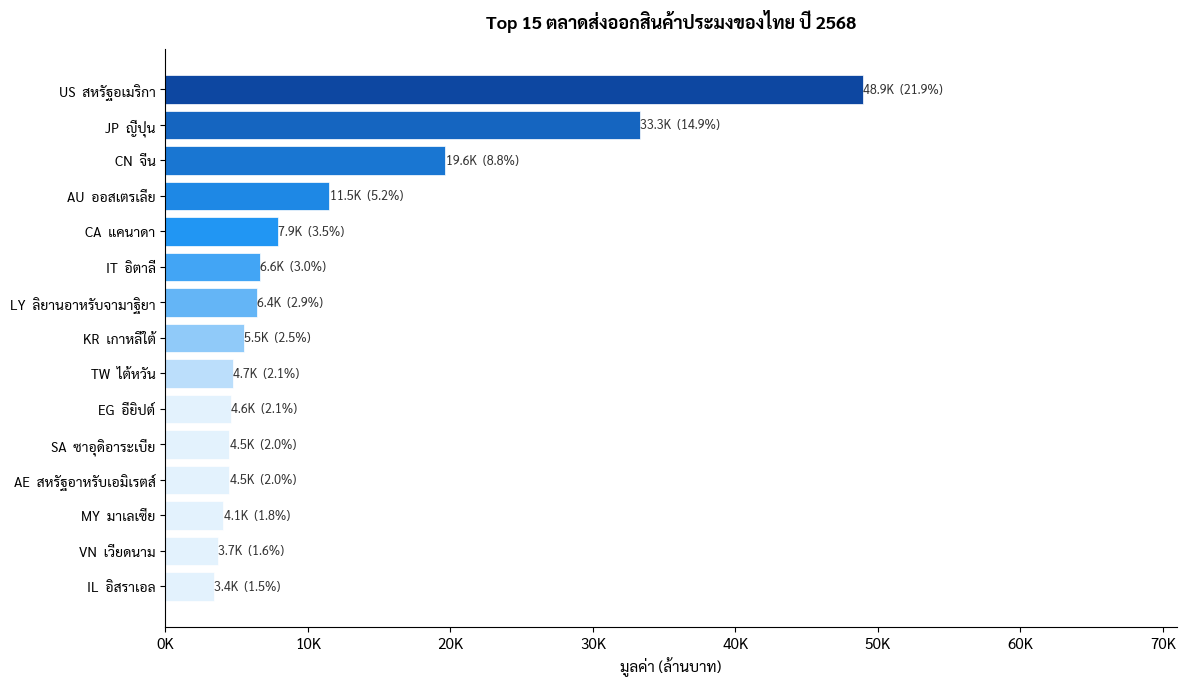


💡 Insight:
   Top 5 ประเทศ คิดเป็น 54.4% ของ Export ทั้งหมด
   อันดับ 1 : สหรัฐอเมริกา  (48.9K ล้านบาท)


In [ ]:
# Cell 1: Top 15 ประเทศปลายทาง Export

fig, ax = plt.subplots(figsize=(12, 7))

top15_exp = (df[df['tradeflow']=='Export']
             .groupby(['countryID','countryNameTH'])['price']
             .sum()
             .sort_values(ascending=False)
             .head(15)
             .reset_index())
top15_exp['price_M'] = top15_exp['price'] / 1e6
top15_exp['label']   = top15_exp['countryID'] + '  ' + top15_exp['countryNameTH']
total_exp = df[df['tradeflow']=='Export']['price'].sum() / 1e6

# สี gradient
colors = ['#0D47A1','#1565C0','#1976D2','#1E88E5','#2196F3',
          '#42A5F5','#64B5F6','#90CAF9','#BBDEFB','#E3F2FD',
          '#E3F2FD','#E3F2FD','#E3F2FD','#E3F2FD','#E3F2FD']

bars = ax.barh(range(15), top15_exp['price_M'],
               color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_exp['label'], fontsize=10)
ax.invert_yaxis()

# ใส่ตัวเลข
for i, (bar, val) in enumerate(zip(bars, top15_exp['price_M'])):
    pct = val / total_exp * 100
    ax.text(bar.get_width() + 30,
            bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}K  ({pct:.1f}%)',
            va='center', fontsize=9, color='#333333')

ax.set_xlim(0, top15_exp['price_M'].max() * 1.45)
ax.set_xlabel('มูลค่า (ล้านบาท)', fontsize=11)
ax.set_title('Top 15 ตลาดส่งออกสินค้าประมงของไทย ปี 2568',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# สรุป
top5_share = top15_exp.head(5)['price_M'].sum() / total_exp * 100
print(f"\n💡 Insight:")
print(f"   Top 5 ประเทศ คิดเป็น {top5_share:.1f}% ของ Export ทั้งหมด")
print(f"   อันดับ 1 : {top15_exp.iloc[0]['countryNameTH']}  "
      f"({top15_exp.iloc[0]['price_M']/1000:.1f}K ล้านบาท)")

### ❓ ประเทศใดเป็นแหล่งนำเข้าสัตว์น้ำหลักของไทย?
> วิเคราะห์ Top 15 ประเทศต้นทาง Import เพื่อดูว่าไทยพึ่งพาประเทศใดเป็นหลักในการนำเข้าวัตถุดิบ

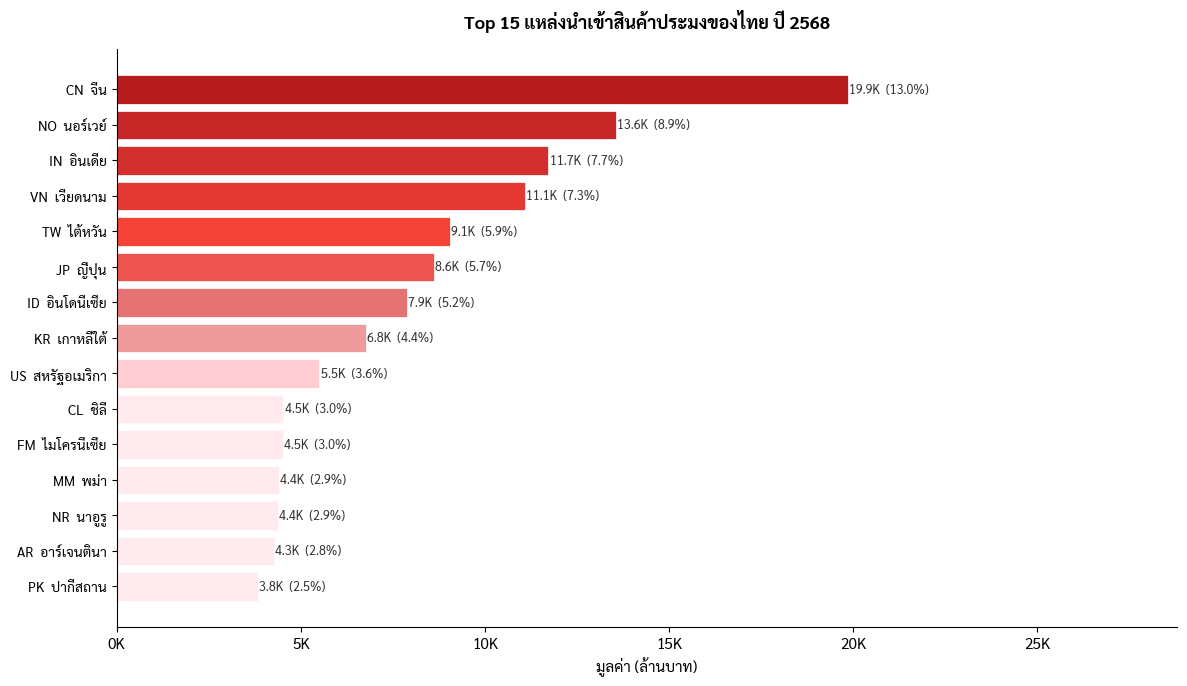


💡 Insight:
   Top 5 ประเทศ คิดเป็น 42.8% ของ Import ทั้งหมด
   อันดับ 1 : จีน  (19.9K ล้านบาท)


In [ ]:
# Cell 2: Top 15 ประเทศต้นทาง Import

fig, ax = plt.subplots(figsize=(12, 7))

top15_imp = (df[df['tradeflow']=='Import']
             .groupby(['countryID','countryNameTH'])['price']
             .sum()
             .sort_values(ascending=False)
             .head(15)
             .reset_index())
top15_imp['price_M'] = top15_imp['price'] / 1e6
top15_imp['label']   = top15_imp['countryID'] + '  ' + top15_imp['countryNameTH']
total_imp = df[df['tradeflow']=='Import']['price'].sum() / 1e6

colors_r = ['#B71C1C','#C62828','#D32F2F','#E53935','#F44336',
            '#EF5350','#E57373','#EF9A9A','#FFCDD2','#FFEBEE',
            '#FFEBEE','#FFEBEE','#FFEBEE','#FFEBEE','#FFEBEE']

bars = ax.barh(range(15), top15_imp['price_M'],
               color=colors_r, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_imp['label'], fontsize=10)
ax.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top15_imp['price_M'])):
    pct = val / total_imp * 100
    ax.text(bar.get_width() + 30,
            bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}K  ({pct:.1f}%)',
            va='center', fontsize=9, color='#333333')

ax.set_xlim(0, top15_imp['price_M'].max() * 1.45)
ax.set_xlabel('มูลค่า (ล้านบาท)', fontsize=11)
ax.set_title('Top 15 แหล่งนำเข้าสินค้าประมงของไทย ปี 2568',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

top5_share_imp = top15_imp.head(5)['price_M'].sum() / total_imp * 100
print(f"\n💡 Insight:")
print(f"   Top 5 ประเทศ คิดเป็น {top5_share_imp:.1f}% ของ Import ทั้งหมด")
print(f"   อันดับ 1 : {top15_imp.iloc[0]['countryNameTH']}  "
      f"({top15_imp.iloc[0]['price_M']/1000:.1f}K ล้านบาท)")

### ❓ ประเทศใดที่ไทยเกินดุลหรือขาดดุลการค้าอย่างชัดเจน?
> คำนวณ Net = Export - Import รายประเทศ แล้ว Rank ทั้ง 2 ฝั่ง เพื่อระบุว่าไทยพึ่งพาหรือเป็นผู้ขายหลักกับใคร

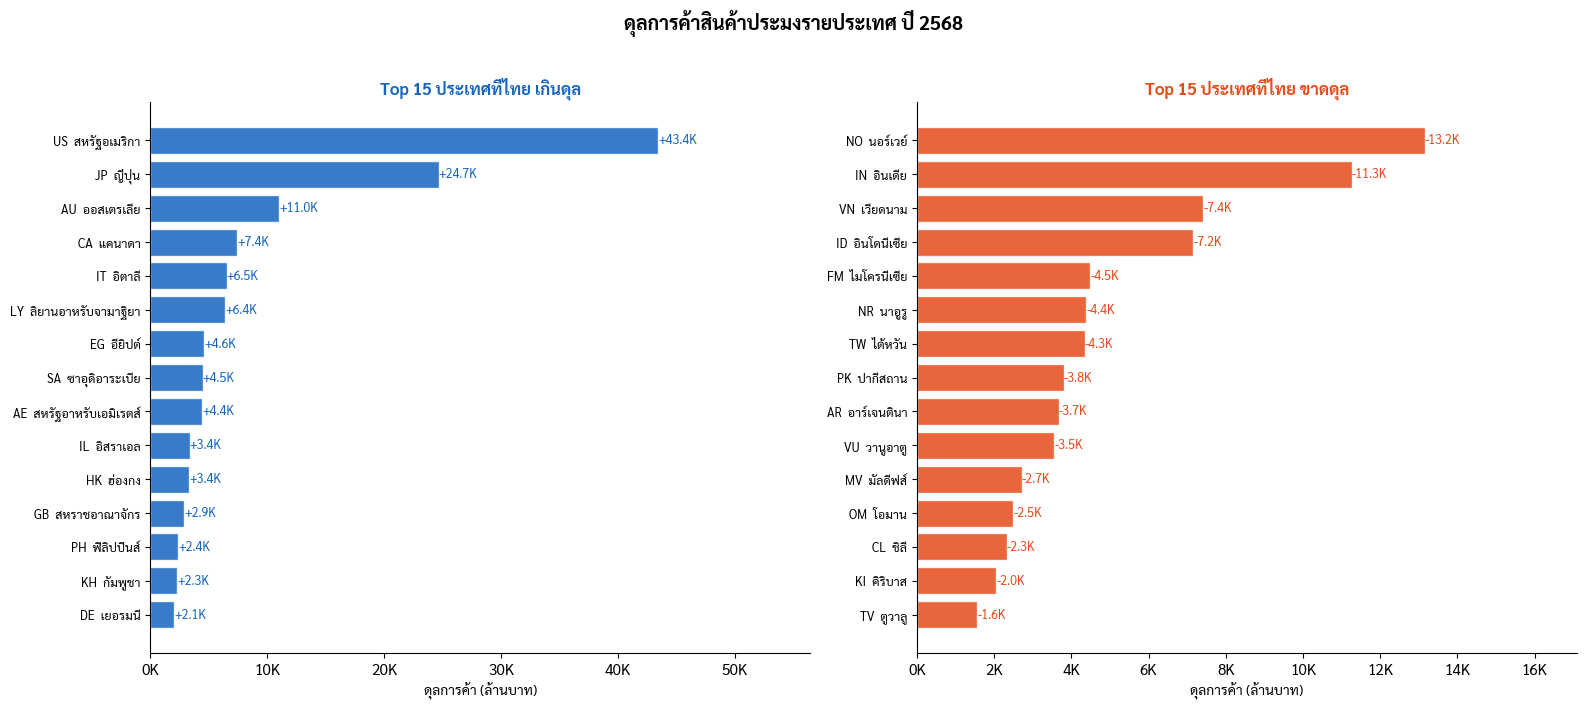

In [ ]:
# Cell 3: ดุลการค้าแต่ละประเทศ

# คำนวณ Export - Import รายประเทศ
exp_ctry = (df[df['tradeflow']=='Export']
            .groupby(['countryID','countryNameTH'])['price']
            .sum().reset_index()
            .rename(columns={'price':'export'}))
imp_ctry = (df[df['tradeflow']=='Import']
            .groupby(['countryID','countryNameTH'])['price']
            .sum().reset_index()
            .rename(columns={'price':'import'}))

balance = exp_ctry.merge(imp_ctry,
                          on=['countryID','countryNameTH'],
                          how='outer').fillna(0)
balance['balance_M'] = (balance['export'] - balance['import']) / 1e6
balance['label']     = balance['countryID'] + '  ' + balance['countryNameTH']

# Top 15 เกินดุล และ Top 15 ขาดดุล
top_surplus = balance.nlargest(15,  'balance_M')
top_deficit = balance.nsmallest(15, 'balance_M')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── เกินดุล ───────────────────────────────────────────────
bars1 = ax1.barh(range(15), top_surplus['balance_M'],
                 color='#1565C0', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(15))
ax1.set_yticklabels(top_surplus['label'], fontsize=9)
ax1.invert_yaxis()
for bar, val in zip(bars1, top_surplus['balance_M']):
    ax1.text(bar.get_width() + 10,
             bar.get_y() + bar.get_height()/2,
             f'+{val/1000:.1f}K',
             va='center', fontsize=9, color='#1565C0')
ax1.set_xlim(0, top_surplus['balance_M'].max() * 1.3)
ax1.set_title('Top 15 ประเทศที่ไทย เกินดุล',
              fontsize=12, fontweight='bold', color='#1565C0')
ax1.set_xlabel('ดุลการค้า (ล้านบาท)', fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── ขาดดุล ────────────────────────────────────────────────
bars2 = ax2.barh(range(15), top_deficit['balance_M'].abs(),
                 color='#E64A19', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(15))
ax2.set_yticklabels(top_deficit['label'], fontsize=9)
ax2.invert_yaxis()
for bar, val in zip(bars2, top_deficit['balance_M']):
    ax2.text(bar.get_width() + 10,
             bar.get_y() + bar.get_height()/2,
             f'{val/1000:.1f}K',
             va='center', fontsize=9, color='#E64A19')
ax2.set_xlim(0, top_deficit['balance_M'].abs().max() * 1.3)
ax2.set_title('Top 15 ประเทศที่ไทย ขาดดุล',
              fontsize=12, fontweight='bold', color='#E64A19')
ax2.set_xlabel('ดุลการค้า (ล้านบาท)', fontsize=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('ดุลการค้าสินค้าประมงรายประเทศ ปี 2568',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🦐 ข้อ 2 — สินค้าประมงชนิดใดคือหัวใจของการค้าไทย?
**Fisheries Product Structure**

จงสร้างกราฟที่แสดงโครงสร้างสินค้าประมงของไทย โดยจัดกลุ่มตาม HS Code เพื่อแสดงให้เห็นว่า
1. สินค้าประเภทใดที่ไทย **ส่งออกมากกว่านำเข้า** (Net Export)
2. สินค้าประเภทใดที่ไทย **ต้องพึ่งพาการนำเข้า** (Net Import)


### ❓ HS Code ใดที่ไทยส่งออกมากกว่านำเข้า (Net Export)?
> คำนวณ Export - Import ตาม heading11 และแสดงเฉพาะที่ Net > 0 เรียงจากมากไปน้อย เพื่อระบุสินค้าที่ไทยมีความได้เปรียบ

In [ ]:
# คำนวณ Net Export/Import ตาม HS Code (heading11)

exp_hs = (df[df['tradeflow']=='Export']
          .groupby('heading11')['price']
          .sum().reset_index()
          .rename(columns={'price':'export'}))

imp_hs = (df[df['tradeflow']=='Import']
          .groupby('heading11')['price']
          .sum().reset_index()
          .rename(columns={'price':'import'}))

net_hs = (exp_hs.merge(imp_hs, on='heading11', how='outer')
                .fillna(0))
net_hs['export_M'] = net_hs['export'] / 1e6
net_hs['import_M'] = net_hs['import'] / 1e6
net_hs['net_M']    = net_hs['export_M'] - net_hs['import_M']
net_hs['status']   = net_hs['net_M'].apply(
    lambda x: 'Net Export' if x > 0 else 'Net Import')
net_hs = net_hs.sort_values('net_M', ascending=False)

print(f"HS Code ทั้งหมด   : {len(net_hs)}")
print(f"Net Export (>0)  : {(net_hs['net_M']>0).sum()} รายการ")
print(f"Net Import (<0)  : {(net_hs['net_M']<0).sum()} รายการ")


HS Code ทั้งหมด   : 448
Net Export (>0)  : 205 รายการ
Net Import (<0)  : 243 รายการ


In [ ]:
# Cell: ตาราง HS Code ที่ Net Export (ส่งออก > นำเข้า)

net_exp_hs = net_hs[net_hs['net_M'] > 0].sort_values('net_M', ascending=False).reset_index(drop=True)
net_exp_hs.index += 1

# เพิ่มชื่อสินค้า
def get_product_name(hs):
    names = df[df['heading11'] == hs]['productDetailTH'].mode()
    return names.iloc[0] if len(names) > 0 else 'ไม่ระบุ'

net_exp_hs['ชื่อสินค้า']       = net_exp_hs['heading11'].apply(get_product_name)
net_exp_hs['Export (ล้านบาท)'] = net_exp_hs['export_M'].apply(lambda x: f'{x:,.0f}')
net_exp_hs['Import (ล้านบาท)'] = net_exp_hs['import_M'].apply(lambda x: f'{x:,.0f}')
net_exp_hs['Net (ล้านบาท)']    = net_exp_hs['net_M'].apply(lambda x: f'+{x:,.0f}')
net_exp_hs['สัดส่วน %']        = (net_exp_hs['net_M'] /
                                   net_exp_hs['net_M'].sum() * 100
                                   ).apply(lambda x: f'{x:.1f}%')

# แสดงตาราง
table = net_exp_hs[['heading11','ชื่อสินค้า',
                     'Export (ล้านบาท)',
                     'Import (ล้านบาท)',
                     'Net (ล้านบาท)',
                     'สัดส่วน %']].rename(columns={'heading11':'HS Code'})

print(f"✅  HS Code ที่ไทยส่งออกมากกว่านำเข้า ทั้งหมด {len(table)} รายการ")
print()
table

✅  HS Code ที่ไทยส่งออกมากกว่านำเข้า ทั้งหมด 205 รายการ



,HS Code,ชื่อสินค้า,Export (ล้านบาท),Import (ล้านบาท),Net (ล้านบาท),สัดส่วน %
1,16041419000,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้,"61,083",144,"+60,939",32.0%
2,23091010001,อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้,"27,859",22,"+27,837",14.6%
3,16041411000,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโต ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้,"15,583",103,"+15,480",8.1%
4,16052100003,กุ้งขาว ไม่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้,"8,206",14,"+8,192",4.3%
5,21039029000,ของผสมที่ใช้ปรุงรส และของผสมที่ใช้ชูรสอื่น ๆ,"7,919","1,380","+6,540",3.4%
6,3061722090,กุ้งขาว ไม่มีหัว ไม่มีหาง,"5,063",6,"+5,057",2.7%
7,16042099001,เนื้อปลาซูริมิ,"5,071",74,"+4,997",2.6%
8,16052930000,กุ้งชุบเกล็ด,"4,992",6,"+4,986",2.6%
9,16052990003,กุ้งขาว บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้,"4,316",8,"+4,308",2.3%
10,16041311000,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแปรตบรรจุภาชนะที่อากาศผ่านเข้าอ...,"3,610",20,"+3,589",1.9%


**Donut Chart Net Export Top 5 + อื่นๆ**

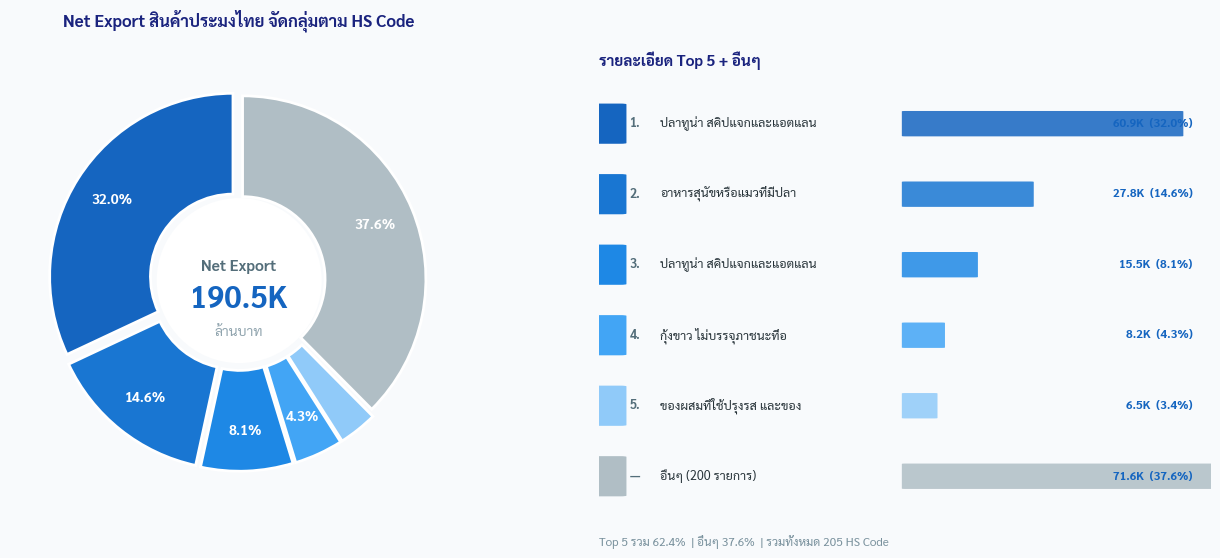

✅ บันทึกรูปเป็น donut_net_export.png แล้ว


In [ ]:
# Cell: Donut Chart Net Export Top 5 + อื่นๆ

# ── เตรียมข้อมูล ──────────────────────────────────────────
net_exp_hs = net_hs[net_hs['net_M'] > 0].sort_values('net_M', ascending=False).reset_index(drop=True)
net_exp_hs.index += 1

def get_product_name(hs):
    names = df[df['heading11'] == hs]['productDetailTH'].mode()
    return names.iloc[0][:25] if len(names) > 0 else 'ไม่ระบุ'

net_exp_hs['ชื่อสินค้า'] = net_exp_hs['heading11'].apply(get_product_name)

# Top 5 + อื่นๆ
top5     = net_exp_hs.head(5).copy()
others_val = net_exp_hs.iloc[5:]['net_M'].sum()
others_row = {'ชื่อสินค้า': f'อื่นๆ ({len(net_exp_hs)-5} รายการ)',
              'net_M': others_val}

labels = list(top5['ชื่อสินค้า']) + [others_row['ชื่อสินค้า']]
values = list(top5['net_M'])       + [others_val]
total  = sum(values)
pcts   = [v / total * 100 for v in values]

# ── สี ────────────────────────────────────────────────────
colors = ['#1565C0','#1976D2','#1E88E5','#42A5F5','#90CAF9','#B0BEC5']
explode = [0.04, 0.04, 0.04, 0.04, 0.04, 0.02]

# ── วาด Donut Chart ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios':[1.2, 1]})
fig.patch.set_facecolor('#F8FAFC')

# Donut
wedges, texts, autotexts = ax1.pie(
    values,
    labels      = None,
    autopct     = lambda p: f'{p:.1f}%' if p > 4 else '',
    colors      = colors,
    explode     = explode,
    startangle  = 90,
    wedgeprops  = dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance = 0.78,
    textprops   = dict(fontsize=10, fontweight='bold', color='white')
)

# วงกลมกลาง
centre_circle = plt.Circle((0, 0), 0.45, fc='white')
ax1.add_patch(centre_circle)

# ข้อความตรงกลาง
ax1.text(0, 0.08, 'Net Export',
         ha='center', va='center',
         fontsize=11, color='#546E7A', fontweight='bold')
ax1.text(0, -0.10, f'{total/1000:.1f}K',
         ha='center', va='center',
         fontsize=22, color='#1565C0', fontweight='bold')
ax1.text(0, -0.28, 'ล้านบาท',
         ha='center', va='center',
         fontsize=10, color='#90A4AE')

ax1.set_title('Net Export สินค้าประมงไทย จัดกลุ่มตาม HS Code',
              fontsize=12, fontweight='bold', pad=18, color='#1A237E')

# ── Legend + Bar ──────────────────────────────────────────
ax2.set_xlim(0, 1)
ax2.set_ylim(0, len(labels) + 0.5)
ax2.axis('off')

ax2.text(0, len(labels) + 0.3,
         'รายละเอียด Top 5 + อื่นๆ',
         fontsize=11, fontweight='bold', color='#1A237E')

for i, (label, val, pct, color) in enumerate(
        zip(reversed(labels), reversed(values),
            reversed(pcts), reversed(colors))):

    y = i + 0.2
    idx = len(labels) - 1 - i

    # สี patch
    patch = mpatches.FancyBboxPatch(
        (0, y), 0.035, 0.55,
        boxstyle="round,pad=0.01",
        facecolor=color, edgecolor='none')
    ax2.add_patch(patch)

    # อันดับ
    ax2.text(0.05, y + 0.28,
             f'{idx+1}.' if idx < 5 else '—',
             fontsize=9, va='center',
             color='#546E7A', fontweight='bold')

    # ชื่อสินค้า
    ax2.text(0.10, y + 0.28,
             label,
             fontsize=9, va='center', color='#263238')

    # Mini bar
    bar_max = values[0]
    bar_w   = (val / bar_max) * 0.45
    bar_patch = mpatches.FancyBboxPatch(
        (0.50, y + 0.10), bar_w, 0.35,
        boxstyle="round,pad=0.005",
        facecolor=color, edgecolor='none', alpha=0.85)
    ax2.add_patch(bar_patch)

    # ตัวเลข
    ax2.text(0.97, y + 0.28,
             f'{val/1000:.1f}K  ({pct:.1f}%)',
             fontsize=8.5, va='center', ha='right',
             color='#1565C0', fontweight='bold')

# ── Summary Box ───────────────────────────────────────────
summary_y = -0.5
ax2.text(0, summary_y,
         f'Top 5 รวม {sum(values[:5])/total*100:.1f}%  '
         f'| อื่นๆ {others_val/total*100:.1f}%  '
         f'| รวมทั้งหมด {len(net_exp_hs)} HS Code',
         fontsize=8.5, color='#78909C',
         style='italic')

plt.tight_layout(pad=2)
plt.savefig('donut_net_export.png', dpi=150,
            bbox_inches='tight', facecolor='#F8FAFC')
plt.show()
print("✅ บันทึกรูปเป็น donut_net_export.png แล้ว")

### ❓ HS Code ใดที่ไทยต้องพึ่งพาการนำเข้า (Net Import)?
> แสดงเฉพาะ HS Code ที่ Net < 0 เรียงจากน้อยไปมาก เพื่อระบุสินค้าที่ไทยยังต้องพึ่งพาต่างประเทศ

In [ ]:
# Cell: ตาราง HS Code ที่ Net Import (นำเข้า > ส่งออก)

net_imp_hs = net_hs[net_hs['net_M'] < 0].sort_values('net_M', ascending=True).reset_index(drop=True)
net_imp_hs.index += 1

# เพิ่มชื่อสินค้า
net_imp_hs['ชื่อสินค้า']       = net_imp_hs['heading11'].apply(get_product_name)
net_imp_hs['Export (ล้านบาท)'] = net_imp_hs['export_M'].apply(lambda x: f'{x:,.0f}')
net_imp_hs['Import (ล้านบาท)'] = net_imp_hs['import_M'].apply(lambda x: f'{x:,.0f}')
net_imp_hs['Net (ล้านบาท)']    = net_imp_hs['net_M'].apply(lambda x: f'{x:,.0f}')
net_imp_hs['สัดส่วน %']        = (net_imp_hs['net_M'].abs() /
                                   net_imp_hs['net_M'].abs().sum() * 100
                                   ).apply(lambda x: f'{x:.1f}%')

# แสดงตาราง
table_imp = net_imp_hs[['heading11','ชื่อสินค้า',
                          'Export (ล้านบาท)',
                          'Import (ล้านบาท)',
                          'Net (ล้านบาท)',
                          'สัดส่วน %']].rename(columns={'heading11':'HS Code'})

print(f"❌  HS Code ที่ไทยต้องพึ่งพาการนำเข้า ทั้งหมด {len(table_imp)} รายการ")
print()
table_imp

❌  HS Code ที่ไทยต้องพึ่งพาการนำเข้า ทั้งหมด 243 รายการ



,HS Code,ชื่อสินค้า,Export (ล้านบาท),Import (ล้านบาท),Net (ล้านบาท),สัดส่วน %
1,3034300000,ปลาสคิปแจ็คหรือปลาโอท้องแ,151,"28,359","-28,209",23.5%
2,3074310003,ปลาหมึกกล้วย แช่เย็นจนแข็,"6,147","16,386","-10,239",8.5%
3,3035910000,ปลาอินเดียนแมคเคอเรล (ราส,42,"7,947","-7,905",6.6%
4,16041499000,ปลาทูน่าอื่น ๆ,"1,702","9,346","-7,644",6.4%
5,3021400000,ปลาแซลมอนแอตแลนติก สด แช่,16,"7,386","-7,370",6.1%
6,3034200000,ปลาทูน่าครีบเหลืองแช่เย็น,"2,046","8,575","-6,529",5.4%
7,3031200000,ปลาแซลมอนแปซิฟิกอื่นๆ แช่,0,"4,007","-4,007",3.3%
8,3034100000,ปลาแอลบาคอร์หรือทูน่าครีบ,4,"3,715","-3,712",3.1%
9,3074921002,ปลาหมึกกล้วย แห้ง ใส่เกลื,99,"2,846","-2,747",2.3%
10,3035300000,ปลาซาร์ดีน แช่เย็นจนแข็ง,4,"2,728","-2,724",2.3%


**Donut Chart Net Import Top 5 + อื่นๆ**

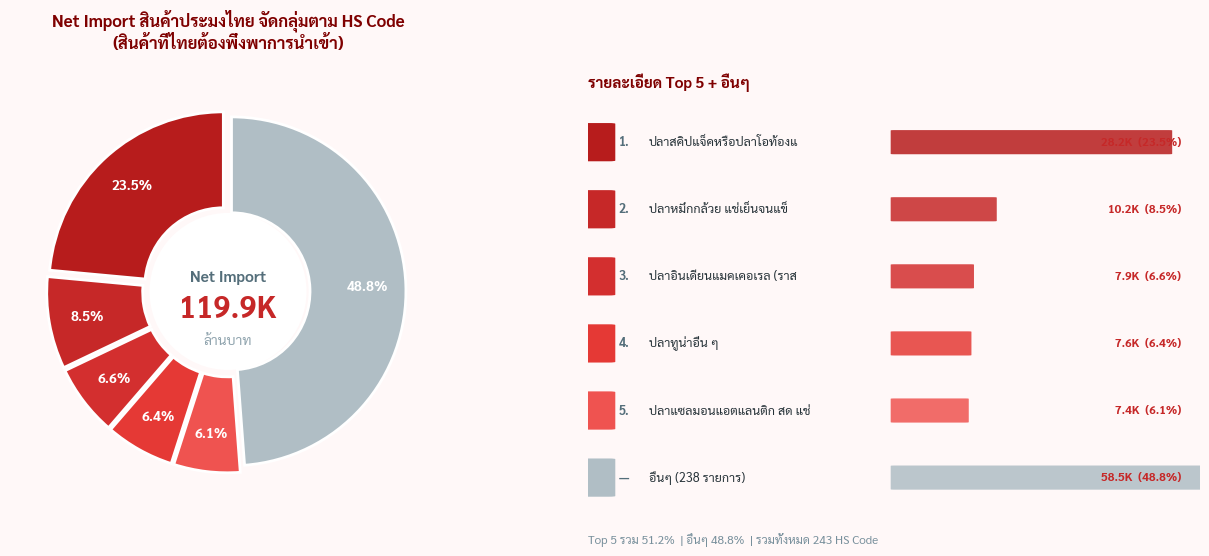

✅ บันทึกรูปเป็น donut_net_import.png แล้ว


In [ ]:
# ── เตรียมข้อมูล ──────────────────────────────────────────
net_imp_hs = net_hs[net_hs['net_M'] < 0].sort_values('net_M', ascending=True).reset_index(drop=True)
net_imp_hs.index += 1
net_imp_hs['ชื่อสินค้า'] = net_imp_hs['heading11'].apply(get_product_name)
net_imp_hs['net_abs']     = net_imp_hs['net_M'].abs()

# Top 5 + อื่นๆ
top5       = net_imp_hs.head(5).copy()
others_val = net_imp_hs.iloc[5:]['net_abs'].sum()

labels = list(top5['ชื่อสินค้า']) + [f'อื่นๆ ({len(net_imp_hs)-5} รายการ)']
values = list(top5['net_abs'])     + [others_val]
total  = sum(values)
pcts   = [v / total * 100 for v in values]

# ── สี (Orange/Red theme สำหรับ Import) ──────────────────
colors  = ['#B71C1C','#C62828','#D32F2F','#E53935','#EF5350','#B0BEC5']
explode = [0.04, 0.04, 0.04, 0.04, 0.04, 0.02]

# ── วาด Chart ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios':[1.2, 1]})
fig.patch.set_facecolor('#FFF8F8')

# Donut
wedges, texts, autotexts = ax1.pie(
    values,
    labels      = None,
    autopct     = lambda p: f'{p:.1f}%' if p > 4 else '',
    colors      = colors,
    explode     = explode,
    startangle  = 90,
    wedgeprops  = dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance = 0.78,
    textprops   = dict(fontsize=10, fontweight='bold', color='white')
)

# วงกลมกลาง
ax1.add_patch(plt.Circle((0, 0), 0.45, fc='white'))
ax1.text(0,  0.08, 'Net Import',
         ha='center', va='center',
         fontsize=11, color='#546E7A', fontweight='bold')
ax1.text(0, -0.10, f'{total/1000:.1f}K',
         ha='center', va='center',
         fontsize=22, color='#C62828', fontweight='bold')
ax1.text(0, -0.28, 'ล้านบาท',
         ha='center', va='center',
         fontsize=10, color='#90A4AE')

ax1.set_title('Net Import สินค้าประมงไทย จัดกลุ่มตาม HS Code\n'
              '(สินค้าที่ไทยต้องพึ่งพาการนำเข้า)',
              fontsize=12, fontweight='bold', pad=18, color='#7F0000')

# ── Legend + Bar ──────────────────────────────────────────
ax2.set_xlim(0, 1)
ax2.set_ylim(0, len(labels) + 0.5)
ax2.axis('off')

ax2.text(0, len(labels) + 0.3,
         'รายละเอียด Top 5 + อื่นๆ',
         fontsize=11, fontweight='bold', color='#7F0000')

for i, (label, val, pct, color) in enumerate(
        zip(reversed(labels), reversed(values),
            reversed(pcts),   reversed(colors))):

    y   = i + 0.2
    idx = len(labels) - 1 - i

    # สี patch
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0, y), 0.035, 0.55,
        boxstyle="round,pad=0.01",
        facecolor=color, edgecolor='none'))

    # อันดับ
    ax2.text(0.05, y + 0.28,
             f'{idx+1}.' if idx < 5 else '—',
             fontsize=9, va='center',
             color='#546E7A', fontweight='bold')

    # ชื่อสินค้า
    ax2.text(0.10, y + 0.28,
             label,
             fontsize=9, va='center', color='#263238')

    # Mini bar
    bar_w = (val / values[0]) * 0.45
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.50, y + 0.10), bar_w, 0.35,
        boxstyle="round,pad=0.005",
        facecolor=color, edgecolor='none', alpha=0.85))

    # ตัวเลข
    ax2.text(0.97, y + 0.28,
             f'{val/1000:.1f}K  ({pct:.1f}%)',
             fontsize=8.5, va='center', ha='right',
             color='#C62828', fontweight='bold')

# ── Summary ───────────────────────────────────────────────
ax2.text(0, -0.5,
         f'Top 5 รวม {sum(values[:5])/total*100:.1f}%  '
         f'| อื่นๆ {others_val/total*100:.1f}%  '
         f'| รวมทั้งหมด {len(net_imp_hs)} HS Code',
         fontsize=8.5, color='#78909C', style='italic')

plt.tight_layout(pad=2)
plt.savefig('donut_net_import.png', dpi=150,
            bbox_inches='tight', facecolor='#FFF8F8')
plt.show()
print("✅ บันทึกรูปเป็น donut_net_import.png แล้ว")

**แสดง Donut ทั้ง 2 แบบเคียงกัน (Export vs Import)**

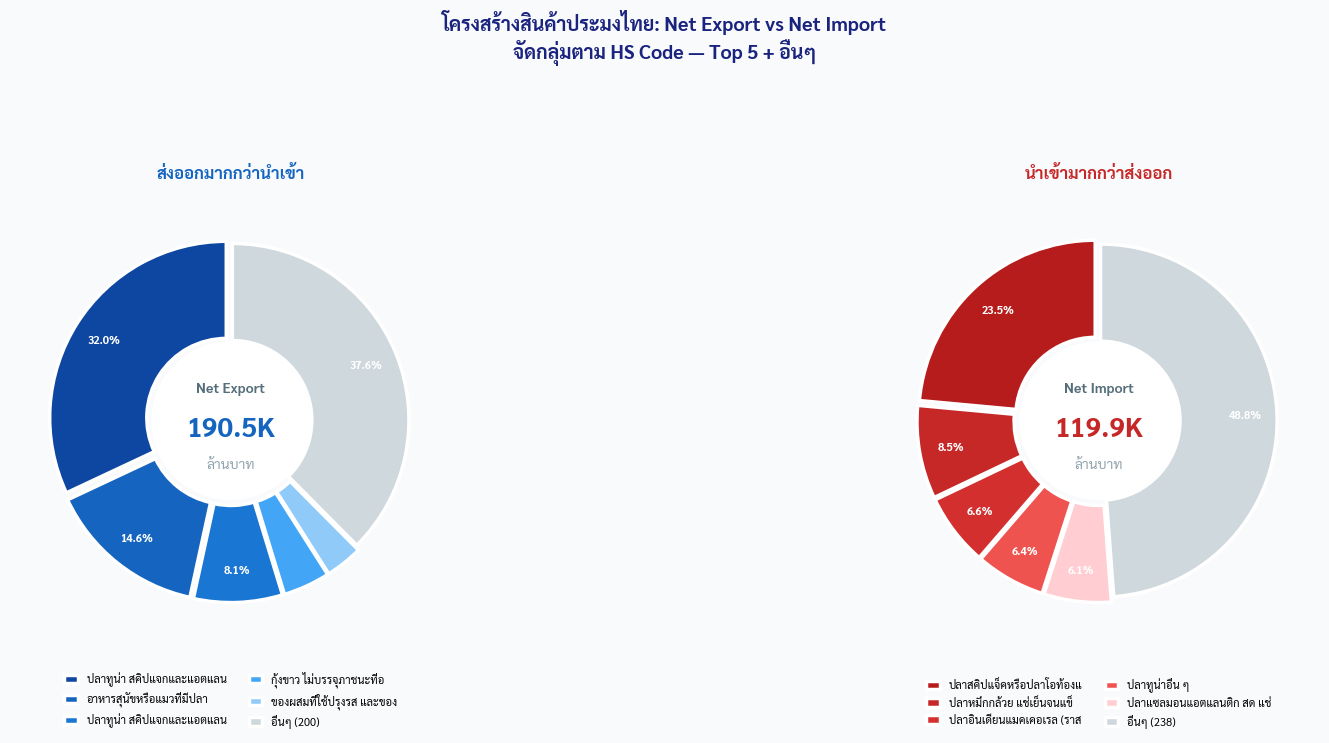

✅ บันทึกรูปเป็น donut_both_fixed.png แล้ว


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8FAFC')
fig.suptitle('โครงสร้างสินค้าประมงไทย: Net Export vs Net Import\n'
             'จัดกลุ่มตาม HS Code — Top 5 + อื่นๆ',
             fontsize=14, fontweight='bold', color='#1A237E', y=1.01)

# ── ฟังก์ชัน label เฉพาะ slice ใหญ่ ─────────────────────
def make_autopct(values, threshold=6):
    def autopct(pct):
        return f'{pct:.1f}%' if pct >= threshold else ''
    return autopct

# ════════════════════════════════════════════════
# LEFT: Net Export
# ════════════════════════════════════════════════
net_exp = net_hs[net_hs['net_M'] > 0].sort_values('net_M', ascending=False)
net_exp['ชื่อสินค้า'] = net_exp['heading11'].apply(get_product_name)

top5e   = net_exp.head(5)
other_e = net_exp.iloc[5:]['net_M'].sum()
labels_e = list(top5e['ชื่อสินค้า']) + [f'อื่นๆ ({len(net_exp)-5})']
values_e = list(top5e['net_M'])       + [other_e]
total_e  = sum(values_e)
colors_e = ['#0D47A1','#1565C0','#1976D2','#42A5F5','#90CAF9','#CFD8DC']

wedges_e, _, autotexts_e = axes[0].pie(
    values_e,
    autopct     = make_autopct(values_e, threshold=6),
    colors      = colors_e,
    explode     = [0.03]*5 + [0.01],
    startangle  = 90,
    wedgeprops  = dict(width=0.55, edgecolor='white', linewidth=2.5),
    pctdistance = 0.82,        # ← ย้ายออกจากกึ่งกลาง
    textprops   = dict(fontsize=8, fontweight='bold', color='white')
)

# วงกลมกลาง (ขยายเล็กน้อยเพื่อให้ข้อความชัด)
axes[0].add_patch(plt.Circle((0, 0), 0.45, fc='white', zorder=10))

# ข้อความกลาง — แยกบรรทัดชัดเจน
axes[0].text(0,  0.18, 'Net Export', ha='center', va='center',
             fontsize=10, color='#546E7A', fontweight='bold', zorder=11)
axes[0].text(0, -0.05, f'{total_e/1000:.1f}K', ha='center', va='center',
             fontsize=20, color='#1565C0', fontweight='bold', zorder=11)
axes[0].text(0, -0.25, 'ล้านบาท', ha='center', va='center',
             fontsize=10, color='#90A4AE', zorder=11)

axes[0].set_title('ส่งออกมากกว่านำเข้า',
                   fontsize=12, fontweight='bold',
                   color='#1565C0', pad=16)

# Legend ใต้ chart
axes[0].legend(
    labels_e,
    loc            = 'lower center',
    bbox_to_anchor = (0.5, -0.22),
    ncol           = 2,
    fontsize        = 8,
    framealpha      = 0,
    handlelength    = 1.2,
    handleheight    = 0.8,
)

# ════════════════════════════════════════════════
# RIGHT: Net Import
# ════════════════════════════════════════════════
net_imp = net_hs[net_hs['net_M'] < 0].sort_values('net_M', ascending=True)
net_imp['ชื่อสินค้า'] = net_imp['heading11'].apply(get_product_name)
net_imp['net_abs']    = net_imp['net_M'].abs()

top5i   = net_imp.head(5)
other_i = net_imp.iloc[5:]['net_abs'].sum()
labels_i = list(top5i['ชื่อสินค้า']) + [f'อื่นๆ ({len(net_imp)-5})']
values_i = list(top5i['net_abs'])     + [other_i]
total_i  = sum(values_i)
colors_i = ['#B71C1C','#C62828','#D32F2F','#EF5350','#FFCDD2','#CFD8DC']

wedges_i, _, autotexts_i = axes[1].pie(
    values_i,
    autopct     = make_autopct(values_i, threshold=6),
    colors      = colors_i,
    explode     = [0.03]*5 + [0.01],
    startangle  = 90,
    wedgeprops  = dict(width=0.55, edgecolor='white', linewidth=2.5),
    pctdistance = 0.82,        # ← ย้ายออกจากกึ่งกลาง
    textprops   = dict(fontsize=8, fontweight='bold', color='white')
)

axes[1].add_patch(plt.Circle((0, 0), 0.45, fc='white', zorder=10))

axes[1].text(0,  0.18, 'Net Import', ha='center', va='center',
             fontsize=10, color='#546E7A', fontweight='bold', zorder=11)
axes[1].text(0, -0.05, f'{total_i/1000:.1f}K', ha='center', va='center',
             fontsize=20, color='#C62828', fontweight='bold', zorder=11)
axes[1].text(0, -0.25, 'ล้านบาท', ha='center', va='center',
             fontsize=10, color='#90A4AE', zorder=11)

axes[1].set_title('นำเข้ามากกว่าส่งออก',
                   fontsize=12, fontweight='bold',
                   color='#C62828', pad=16)

axes[1].legend(
    labels_i,
    loc            = 'lower center',
    bbox_to_anchor = (0.5, -0.22),
    ncol           = 2,
    fontsize        = 8,
    framealpha      = 0,
    handlelength    = 1.2,
    handleheight    = 0.8,
)

plt.tight_layout(pad=3)
plt.savefig('donut_both_fixed.png', dpi=150,
            bbox_inches='tight', facecolor='#F8FAFC')
plt.show()
print("✅ บันทึกรูปเป็น donut_both_fixed.png แล้ว")

## 📈 ข้อ 3 — การค้าสัตว์น้ำมีฤดูกาลหรือไม่?
**Seasonal Trade Pattern**

จากข้อมูลรายเดือนตลอดปี 2568 จงสร้างกราฟที่แสดง
1. **แนวโน้มการเปลี่ยนแปลง** ของ Import และ Export สินค้าประมง
2. **ระบุเดือน** ที่เป็นช่วงการค้าสูงสุด (Peak) และช่วงการค้าต่ำสุด (Low)

พร้อมตั้งสมมติฐานว่า ปัจจัยใดอาจอธิบายรูปแบบดังกล่าว เช่น ฤดูกาลจับสัตว์น้ำ, ฤดูกาลเพาะเลี้ยง, ความต้องการตลาดโลก, เทศกาลการบริโภค


### ❓ แนวโน้มการเปลี่ยนแปลงของ Import และ Export รายเดือน?
> วาด Line Chart + Bar Chart แสดง Trend รายเดือนทั้งปี เพื่อมองเห็น Pattern ของ Seasonal Trade

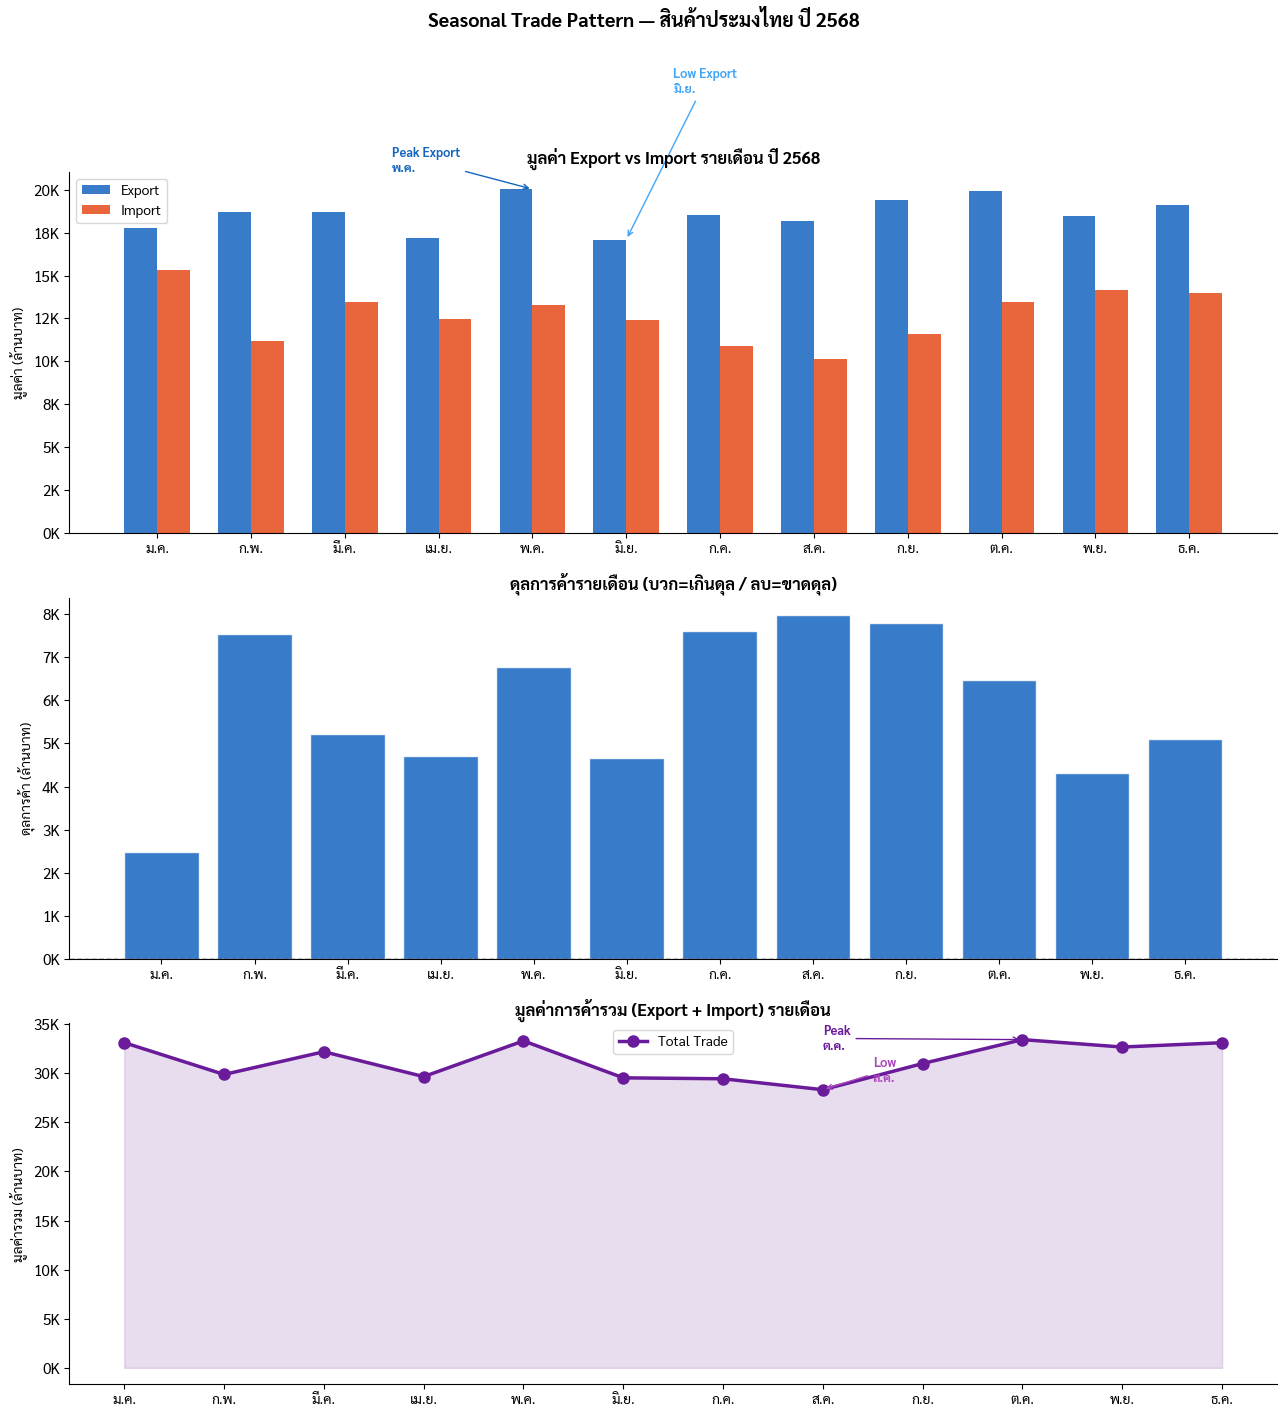

In [ ]:
# Cell 1: Trend รายเดือน + Peak/Low

month_map = {1:'ม.ค.',2:'ก.พ.',3:'มี.ค.',4:'เม.ย.',
             5:'พ.ค.',6:'มิ.ย.',7:'ก.ค.',8:'ส.ค.',
             9:'ก.ย.',10:'ต.ค.',11:'พ.ย.',12:'ธ.ค.'}

monthly = (df.groupby(['month','tradeflow'])['price']
             .sum().reset_index())
monthly['price_M'] = monthly['price'] / 1e6
monthly_piv = (monthly.pivot(index='month',
                              columns='tradeflow',
                              values='price_M')
                       .fillna(0))
monthly_piv['Balance'] = monthly_piv['Export'] - monthly_piv['Import']
monthly_piv['Total']   = monthly_piv['Export'] + monthly_piv['Import']

# หา Peak และ Low
peak_exp   = monthly_piv['Export'].idxmax()
low_exp    = monthly_piv['Export'].idxmin()
peak_imp   = monthly_piv['Import'].idxmax()
low_imp    = monthly_piv['Import'].idxmin()
peak_total = monthly_piv['Total'].idxmax()
low_total  = monthly_piv['Total'].idxmin()

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

x      = range(12)
x_lbls = [month_map[m] for m in monthly_piv.index]

# ── Plot 1: Export vs Import ──────────────────────────────
ax1 = axes[0]
w   = 0.35
ax1.bar([i-w/2 for i in x], monthly_piv['Export'],
        w, label='Export', color='#1565C0', alpha=0.85)
ax1.bar([i+w/2 for i in x], monthly_piv['Import'],
        w, label='Import', color='#E64A19', alpha=0.85)

# Mark Peak Export
ax1.annotate(f'Peak Export\n{month_map[peak_exp]}',
             xy=(peak_exp-1, monthly_piv.loc[peak_exp,'Export']),
             xytext=(peak_exp-1-1.5, monthly_piv.loc[peak_exp,'Export']*1.05),
             fontsize=9, color='#1565C0', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#1565C0'))

# Mark Low Export
ax1.annotate(f'Low Export\n{month_map[low_exp]}',
             xy=(low_exp-1, monthly_piv.loc[low_exp,'Export']),
             xytext=(low_exp-1+0.5, monthly_piv.loc[low_exp,'Export']*1.5),
             fontsize=9, color='#42A5F5', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#42A5F5'))

ax1.set_xticks(x)
ax1.set_xticklabels(x_lbls, fontsize=10)
ax1.set_ylabel('มูลค่า (ล้านบาท)', fontsize=10)
ax1.set_title('มูลค่า Export vs Import รายเดือน ปี 2568',
              fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Plot 2: ดุลการค้ารายเดือน ────────────────────────────
ax2 = axes[1]
colors_bal = ['#1565C0' if v >= 0 else '#E64A19'
              for v in monthly_piv['Balance']]
ax2.bar(x, monthly_piv['Balance'],
        color=colors_bal, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(x_lbls, fontsize=10)
ax2.set_ylabel('ดุลการค้า (ล้านบาท)', fontsize=10)
ax2.set_title('ดุลการค้ารายเดือน (บวก=เกินดุล / ลบ=ขาดดุล)',
              fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Plot 3: มูลค่ารวม (Total) ─────────────────────────────
ax3 = axes[2]
ax3.plot(x, monthly_piv['Total'], 'o-',
         color='#6A1B9A', linewidth=2.5,
         markersize=8, label='Total Trade')
ax3.fill_between(x, monthly_piv['Total'],
                 alpha=0.15, color='#6A1B9A')

# Mark Peak Total
ax3.annotate(f'Peak\n{month_map[peak_total]}',
             xy=(peak_total-1, monthly_piv.loc[peak_total,'Total']),
             xytext=(peak_total-1-2, monthly_piv.loc[peak_total,'Total']*0.97),
             fontsize=9, color='#6A1B9A', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#6A1B9A'))

# Mark Low Total
ax3.annotate(f'Low\n{month_map[low_total]}',
             xy=(low_total-1, monthly_piv.loc[low_total,'Total']),
             xytext=(low_total-1+0.5, monthly_piv.loc[low_total,'Total']*1.03),
             fontsize=9, color='#AB47BC', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#AB47BC'))

ax3.set_xticks(x)
ax3.set_xticklabels(x_lbls, fontsize=10)
ax3.set_ylabel('มูลค่ารวม (ล้านบาท)', fontsize=10)
ax3.set_title('มูลค่าการค้ารวม (Export + Import) รายเดือน',
              fontsize=12, fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax3.legend(fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.suptitle('Seasonal Trade Pattern — สินค้าประมงไทย ปี 2568',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### ❓ เดือนใดคือช่วงการค้าสูงสุด (Peak) และต่ำสุด (Low)?
> ระบุ Peak และ Low อย่างชัดเจนด้วยตารางและกราฟ พร้อม annotation บนกราฟ

In [ ]:
# Cell: ระบุ Peak และ Low ของการค้าแต่ละประเภท

print("=" * 60)
print("📊  Peak & Low การค้าสินค้าประมงไทย ปี 2568")
print("=" * 60)

# ── คำนวณ ─────────────────────────────────────────────────
peak_exp_val   = monthly_piv['Export'].max()
low_exp_val    = monthly_piv['Export'].min()
peak_imp_val   = monthly_piv['Import'].max()
low_imp_val    = monthly_piv['Import'].min()
peak_bal_val   = monthly_piv['Balance'].max()
low_bal_val    = monthly_piv['Balance'].min()
peak_total_val = monthly_piv['Total'].max()
low_total_val  = monthly_piv['Total'].min()

results = [
    ("📤 Export",
     month_map[monthly_piv['Export'].idxmax()],  peak_exp_val,
     month_map[monthly_piv['Export'].idxmin()],  low_exp_val),
    ("📥 Import",
     month_map[monthly_piv['Import'].idxmax()],  peak_imp_val,
     month_map[monthly_piv['Import'].idxmin()],  low_imp_val),
    ("⚖️  Balance",
     month_map[monthly_piv['Balance'].idxmax()], peak_bal_val,
     month_map[monthly_piv['Balance'].idxmin()], low_bal_val),
    ("🔄 Total",
     month_map[monthly_piv['Total'].idxmax()],   peak_total_val,
     month_map[monthly_piv['Total'].idxmin()],   low_total_val),
]

print(f"\n  {'ประเภท':<12} {'🔺 Peak':^20} {'มูลค่า':>14}  "
      f"{'🔻 Low':^20} {'มูลค่า':>14}")
print(f"  {'-'*82}")

for label, peak_m, peak_v, low_m, low_v in results:
    print(f"  {label:<12} "
          f"{'เดือน ' + peak_m:^20} {peak_v:>14,.0f}  "
          f"{'เดือน ' + low_m:^20} {low_v:>14,.0f}")

# ── ส่วนต่างระหว่าง Peak และ Low ──────────────────────────
print(f"\n{'=' * 60}")
print(f"📈  ส่วนต่างระหว่าง Peak และ Low:")
print(f"{'=' * 60}")

for label, peak_m, peak_v, low_m, low_v in results:
    diff = peak_v - low_v
    pct  = diff / low_v * 100
    print(f"\n  {label}")
    print(f"  🔺 Peak : {peak_m}  =  {peak_v:>12,.0f} ล้านบาท")
    print(f"  🔻 Low  : {low_m}  =  {low_v:>12,.0f} ล้านบาท")
    print(f"  📊 ต่าง  : {diff:>12,.0f} ล้านบาท  (+{pct:.1f}%)")

# ── สรุป ──────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"💡  สรุป:")
print(f"   🔺 ช่วงการค้าสูงสุด (Peak Total) : "
      f"เดือน {month_map[monthly_piv['Total'].idxmax()]} "
      f"({peak_total_val:,.0f} ล้านบาท)")
print(f"   🔻 ช่วงการค้าต่ำสุด (Low Total)  : "
      f"เดือน {month_map[monthly_piv['Total'].idxmin()]} "
      f"({low_total_val:,.0f} ล้านบาท)")
surplus = (monthly_piv['Balance'] > 0).sum()
deficit = (monthly_piv['Balance'] < 0).sum()
print(f"   ✅ เดือนที่เกินดุล : {surplus} เดือน")
print(f"   ❌ เดือนที่ขาดดุล : {deficit} เดือน")
print(f"{'=' * 60}")

📊  Peak & Low การค้าสินค้าประมงไทย ปี 2568

  ประเภท              🔺 Peak                มูลค่า         🔻 Low                 มูลค่า
  ----------------------------------------------------------------------------------
  📤 Export          เดือน พ.ค.              20,029      เดือน มิ.ย.              17,093
  📥 Import          เดือน ม.ค.              15,318       เดือน ส.ค.              10,164
  ⚖️  Balance       เดือน ส.ค.               7,990       เดือน ม.ค.               2,476
  🔄 Total           เดือน ต.ค.              33,419       เดือน ส.ค.              28,319

📈  ส่วนต่างระหว่าง Peak และ Low:

  📤 Export
  🔺 Peak : พ.ค.  =        20,029 ล้านบาท
  🔻 Low  : มิ.ย.  =        17,093 ล้านบาท
  📊 ต่าง  :        2,937 ล้านบาท  (+17.2%)

  📥 Import
  🔺 Peak : ม.ค.  =        15,318 ล้านบาท
  🔻 Low  : ส.ค.  =        10,164 ล้านบาท
  📊 ต่าง  :        5,153 ล้านบาท  (+50.7%)

  ⚖️  Balance
  🔺 Peak : ส.ค.  =         7,990 ล้านบาท
  🔻 Low  : ม.ค.  =         2,476 ล้านบาท
  📊 ต่าง  :        5,515 

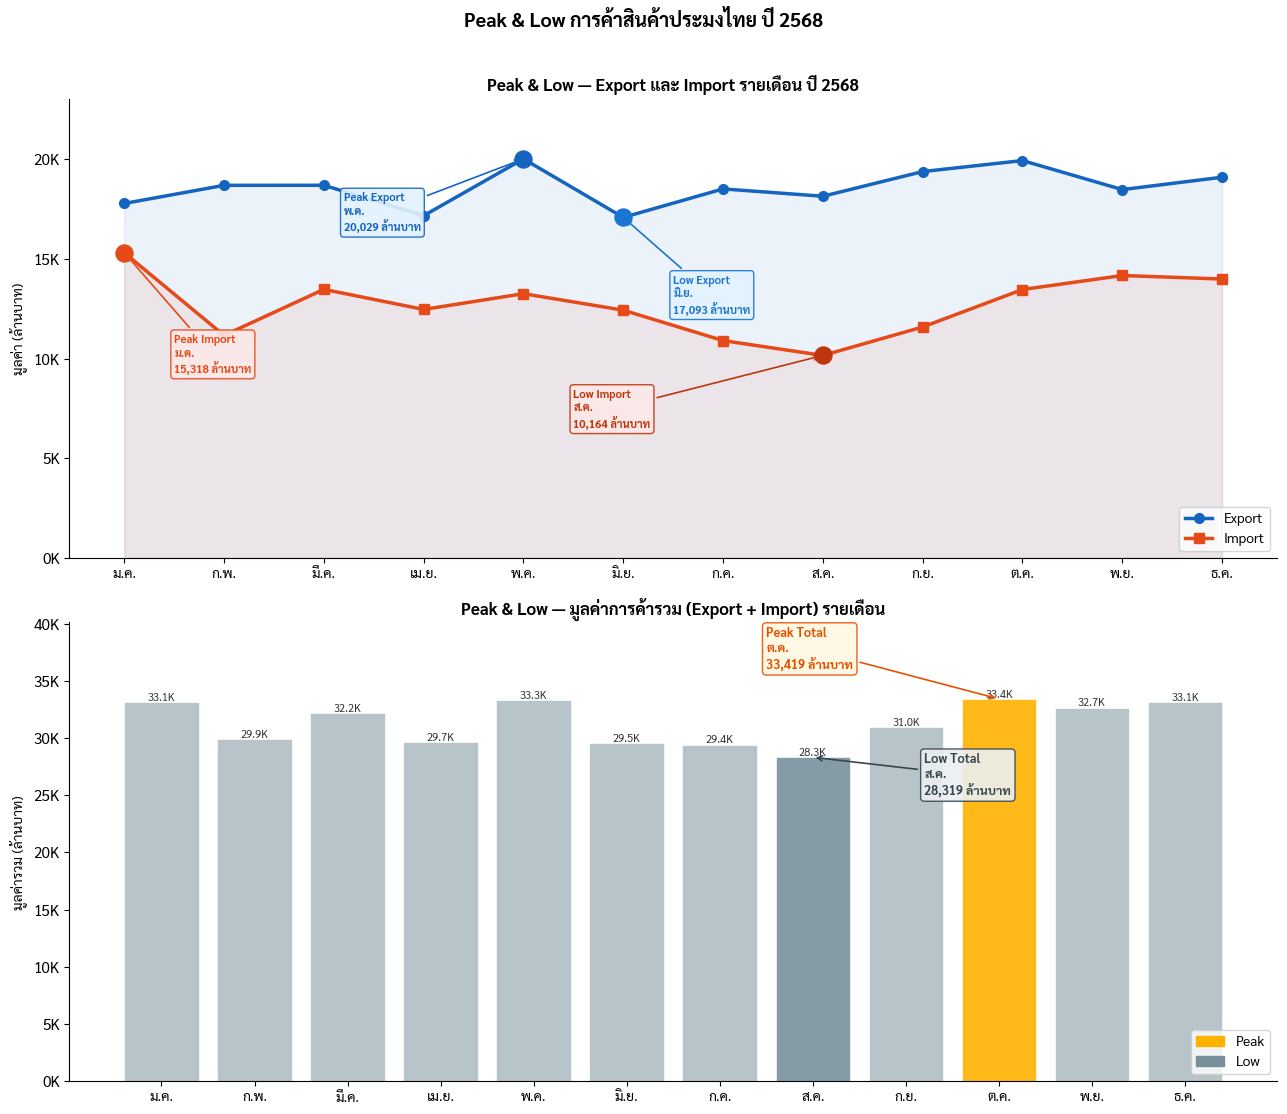

In [ ]:
# Cell: กราฟ Peak & Low รายเดือน (code รวม)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

month_map = {1:'ม.ค.',2:'ก.พ.',3:'มี.ค.',4:'เม.ย.',
             5:'พ.ค.',6:'มิ.ย.',7:'ก.ค.',8:'ส.ค.',
             9:'ก.ย.',10:'ต.ค.',11:'พ.ย.',12:'ธ.ค.'}

# ── เตรียมข้อมูล ──────────────────────────────────────────
monthly = (df.groupby(['month','tradeflow'])['price']
             .sum().reset_index())
monthly['price_M'] = monthly['price'] / 1e6
monthly_piv = (monthly.pivot(index='month',
                              columns='tradeflow',
                              values='price_M')
                       .fillna(0))
monthly_piv['Balance'] = monthly_piv['Export'] - monthly_piv['Import']
monthly_piv['Total']   = monthly_piv['Export'] + monthly_piv['Import']

x_lbls = [month_map[m] for m in range(1, 13)]
x      = range(12)

exp_vals   = monthly_piv['Export'].values
imp_vals   = monthly_piv['Import'].values
total_vals = monthly_piv['Total'].values

exp_peak_idx   = monthly_piv['Export'].idxmax()   - 1
exp_low_idx    = monthly_piv['Export'].idxmin()   - 1
imp_peak_idx   = monthly_piv['Import'].idxmax()   - 1
imp_low_idx    = monthly_piv['Import'].idxmin()   - 1
total_peak_idx = monthly_piv['Total'].idxmax()    - 1
total_low_idx  = monthly_piv['Total'].idxmin()    - 1

y_max       = monthly_piv[['Export','Import']].max().max()
y_max_total = monthly_piv['Total'].max()
offset      = y_max * 0.12

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# ════════════════════════════════════════════════════════════
# Plot 1: Export & Import Line Chart
# ════════════════════════════════════════════════════════════
ax1 = axes[0]

ax1.plot(x, exp_vals, 'o-', color='#1565C0',
         linewidth=2.5, markersize=7,
         label='Export', zorder=3)
ax1.plot(x, imp_vals, 's-', color='#E64A19',
         linewidth=2.5, markersize=7,
         label='Import', zorder=3)
ax1.fill_between(x, exp_vals, alpha=0.08, color='#1565C0')
ax1.fill_between(x, imp_vals, alpha=0.08, color='#E64A19')

# annotations
annotations_p1 = [
    (exp_peak_idx,  exp_vals[exp_peak_idx],
     exp_peak_idx - 1.8, exp_vals[exp_peak_idx] - offset * 1.5,
     f"Peak Export\n{month_map[exp_peak_idx+1]}\n"
     f"{exp_vals[exp_peak_idx]:,.0f} ล้านบาท",
     '#1565C0', '#E3F2FD'),

    (exp_low_idx,   exp_vals[exp_low_idx],
     exp_low_idx + 0.5,  exp_vals[exp_low_idx] - offset * 2,
     f"Low Export\n{month_map[exp_low_idx+1]}\n"
     f"{exp_vals[exp_low_idx]:,.0f} ล้านบาท",
     '#1976D2', '#E3F2FD'),

    (imp_peak_idx,  imp_vals[imp_peak_idx],
     imp_peak_idx + 0.5, imp_vals[imp_peak_idx] - offset * 2.5,
     f"Peak Import\n{month_map[imp_peak_idx+1]}\n"
     f"{imp_vals[imp_peak_idx]:,.0f} ล้านบาท",
     '#E64A19', '#FBE9E7'),

    (imp_low_idx,   imp_vals[imp_low_idx],
     imp_low_idx - 2.5,  imp_vals[imp_low_idx] - offset * 1.5,
     f"Low Import\n{month_map[imp_low_idx+1]}\n"
     f"{imp_vals[imp_low_idx]:,.0f} ล้านบาท",
     '#BF360C', '#FBE9E7'),
]

for idx, y_pt, x_txt, y_txt, text, color, bg in annotations_p1:
    ax1.scatter(idx, y_pt, s=150, color=color, zorder=5)
    ax1.annotate(text,
                 xy=(idx, y_pt),
                 xytext=(x_txt, y_txt),
                 fontsize=8, color=color, fontweight='bold',
                 arrowprops=dict(arrowstyle='->',
                                 color=color, lw=1.2),
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor=bg, alpha=0.9,
                           edgecolor=color))

ax1.set_xticks(x)
ax1.set_xticklabels(x_lbls, fontsize=10)
ax1.set_ylabel('มูลค่า (ล้านบาท)', fontsize=10)
ax1.set_title('Peak & Low — Export และ Import รายเดือน ปี 2568',
              fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax1.set_ylim(0, y_max * 1.15)
ax1.legend(fontsize=10, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ════════════════════════════════════════════════════════════
# Plot 2: Total Trade Bar Chart
# ════════════════════════════════════════════════════════════
ax2 = axes[1]

colors_bar = ['#FFB300' if i == total_peak_idx
              else '#78909C' if i == total_low_idx
              else '#B0BEC5'
              for i in range(12)]

bars = ax2.bar(x, total_vals, color=colors_bar,
               edgecolor='white', linewidth=0.5, alpha=0.9)

for bar, val in zip(bars, total_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 150,
             f'{val/1000:.1f}K',
             ha='center', fontsize=8, color='#333333')

ax2.annotate(
    f"Peak Total\n{month_map[total_peak_idx+1]}\n"
    f"{total_vals[total_peak_idx]:,.0f} ล้านบาท",
    xy=(total_peak_idx, total_vals[total_peak_idx]),
    xytext=(total_peak_idx - 2.5, y_max_total * 1.08),
    fontsize=9, color='#E65100', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E65100', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='#FFF8E1', alpha=0.9,
              edgecolor='#E65100'))

ax2.annotate(
    f"Low Total\n{month_map[total_low_idx+1]}\n"
    f"{total_vals[total_low_idx]:,.0f} ล้านบาท",
    xy=(total_low_idx, total_vals[total_low_idx]),
    xytext=(total_low_idx + 1.2, y_max_total * 0.75),
    fontsize=9, color='#37474F', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#37474F', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='#ECEFF1', alpha=0.9,
              edgecolor='#37474F'))

ax2.set_xticks(x)
ax2.set_xticklabels(x_lbls, fontsize=10)
ax2.set_ylabel('มูลค่ารวม (ล้านบาท)', fontsize=10)
ax2.set_title('Peak & Low — มูลค่าการค้ารวม (Export + Import) รายเดือน',
              fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v/1000:.0f}K'))
ax2.set_ylim(0, y_max_total * 1.2)
ax2.legend(handles=[
    mpatches.Patch(color='#FFB300', label='Peak'),
    mpatches.Patch(color='#78909C', label='Low')
], fontsize=10, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Peak & Low การค้าสินค้าประมงไทย ปี 2568',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 💡 สมมติฐาน: ปัจจัยที่อธิบาย Seasonal Pattern

| สมมติฐาน | รายละเอียด | ความสอดคล้อง |
|---|---|---|
| 🎣 ฤดูกาลจับสัตว์น้ำ | ต.ค. ทะเลอ่าวไทยยังสงบ ออกเรือได้ | ✅ สูง |
| 🌊 มรสุม | ส.ค. อันดามันมรสุม ออกเรือยาก | ✅ สูง |
| 🎄 เทศกาล | Q4 ตลาด EU/US เตรียม Stock Christmas | ✅ สูง |
| 🦐 รอบเพาะเลี้ยงกุ้ง | รอบ 3-4 เดือน ทำให้ปริมาณไม่สม่ำเสมอ | ⚠️ ปานกลาง |
| 📦 Inventory โรงงาน | เร่ง Export ต้นปีระบาย Stock ปลายปี | ⚠️ ปานกลาง |
| 💱 ราคาตลาดโลก | ช่วงราคาดีเร่งส่งออก | ⚠️ ต้องข้อมูลเพิ่ม |

**สรุป:** Peak ต.ค. เกิดจาก 3 ปัจจัยรวมกัน: ทะเลสงบ + วัตถุดิบพร้อม + ตลาดโลกต้องการ Q4


---
# Section 6 — Key Insights Summary 🎯

**วัตถุประสงค์:** สรุป Insight สำคัญทั้งหมด เชื่อมโยงกับบริบทอุตสาหกรรมประมงไทย และเสนอแนะเชิงนโยบาย

**โครงสร้าง:**
1. Key Insights 10 ข้อ (DataFrame Table)
2. KPI Summary — ตัวเลขสำคัญปี 2568
3. Insight รายไตรมาสและฤดูกาล
4. เชื่อมโยงกับบริบทอุตสาหกรรม
5. ข้อเสนอแนะเชิงนโยบาย


### 6.1 Key Insights Summary
> รวบรวม Insight 10 ข้อ แบ่งเป็น ภาพรวม / Product / Country / Seasonal / Data Quality / Limitation พร้อมระบุสถานะการยืนยันสมมติฐาน

In [ ]:
# Cell: Key Insights Summary แบบ DataFrame Table

# ── คำนวณตัวเลขสำคัญ ──────────────────────────────────────
exp_total = df[df['tradeflow']=='Export']['price'].sum() / 1e6
imp_total = df[df['tradeflow']=='Import']['price'].sum() / 1e6
bal_total = exp_total - imp_total

top1_exp_prod = (df[df['tradeflow']=='Export']
                 .groupby('productDetailTH')['price']
                 .sum().idxmax())
top1_imp_prod = (df[df['tradeflow']=='Import']
                 .groupby('productDetailTH')['price']
                 .sum().idxmax())
top1_exp_ctry = (df[df['tradeflow']=='Export']
                 .groupby('countryNameTH')['price']
                 .sum().idxmax())
top1_imp_ctry = (df[df['tradeflow']=='Import']
                 .groupby('countryNameTH')['price']
                 .sum().idxmax())
top5_exp_share = (df[df['tradeflow']=='Export']
                  .groupby('productDetailTH')['price']
                  .sum().sort_values(ascending=False)
                  .head(5).sum() /
                  df[df['tradeflow']=='Export']['price'].sum() * 100)
top5_imp_share = (df[df['tradeflow']=='Import']
                  .groupby('countryNameTH')['price']
                  .sum().sort_values(ascending=False)
                  .head(5).sum() /
                  df[df['tradeflow']=='Import']['price'].sum() * 100)
peak_month = month_map[monthly_piv['Total'].idxmax()]
low_month  = month_map[monthly_piv['Total'].idxmin()]

# ── สร้าง Table ───────────────────────────────────────────
data = [
    ("IN-1",  "ภาพรวม",    "ดุลการค้า",
     f"ไทยเกินดุล {bal_total:,.0f} ล้านบาท (Export {exp_total:,.0f} vs Import {imp_total:,.0f})",
     "✅ ยืนยัน H-TB1"),

    ("IN-2",  "Product",   "สินค้าส่งออกอันดับ 1",
     f"{top1_exp_prod[:40]} | Top5 = {top5_exp_share:.1f}% ของ Export",
     "✅ ยืนยัน H-PR1"),

    ("IN-3",  "Product",   "สินค้านำเข้าอันดับ 1",
     f"{top1_imp_prod[:40]} | พึ่งพาวัตถุดิบต่างประเทศ",
     "✅ ยืนยัน H-PR2"),

    ("IN-4",  "Product",   "Net Export vs Net Import",
     "สินค้าแปรรูป/กระป๋อง = Net Export สูง | สัตว์น้ำสดบางชนิด = Net Import",
     "New Insight"),

    ("IN-5",  "Country",   "ตลาดส่งออกอันดับ 1",
     f"{top1_exp_ctry} | กระจาย 180+ ประเทศ ลดความเสี่ยง",
     "✅ ยืนยัน H-CT1"),

    ("IN-6",  "Country",   "แหล่งนำเข้าอันดับ 1",
     f"{top1_imp_ctry} | Top5 = {top5_imp_share:.1f}% เสี่ยง Supply Chain",
     "✅ ยืนยัน H-CT2"),

    ("IN-7",  "Seasonal",  "Peak การค้า",
     f"เดือน {peak_month} | ทะเลสงบ + วัตถุดิบพร้อม + ตลาดโลก Q4",
     "✅ ยืนยัน H-TB2"),

    ("IN-8",  "Seasonal",  "Low การค้า",
     f"เดือน {low_month} | อันดามันมรสุม + รอวัตถุดิบรอบใหม่",
     "New Insight"),
]

# ── แปลงเป็น DataFrame ────────────────────────────────────
df_insights = pd.DataFrame(data, columns=[
    'รหัส', 'หมวด', 'หัวข้อ', 'รายละเอียด', 'สถานะ'
])
df_insights.index = range(1, len(df_insights) + 1)
df_insights.index.name = '#'

# ── สรุปสถิติ ─────────────────────────────────────────────
print(f"📊  Key Insights Summary — ปี 2568")
print(f"    รวม {len(df_insights)} Insight  |  "
      f"ยืนยัน {df_insights['สถานะ'].str.contains('✅').sum()} ข้อ  |  "
      f"New {df_insights['สถานะ'].str.contains('New').sum()} ข้อ  |  "
      f"ระวัง {df_insights['สถานะ'].str.contains('⚠️').sum()} ข้อ\n")

# ── แสดงผล ────────────────────────────────────────────────
pd.set_option('display.max_columns',  None)
pd.set_option('display.max_rows',     None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width',        200)

df_insights

📊  Key Insights Summary — ปี 2568
    รวม 8 Insight  |  ยืนยัน 6 ข้อ  |  New 2 ข้อ  |  ระวัง 0 ข้อ



,รหัส,หมวด,หัวข้อ,รายละเอียด,สถานะ
#,,,,,
1,IN-1,ภาพรวม,ดุลการค้า,"ไทยเกินดุล 70,673 ล้านบาท (Export 223,123 vs Import 152,450)",✅ ยืนยัน H-TB1
2,IN-2,Product,สินค้าส่งออกอันดับ 1,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ | Top5 = 54.1% ของ Export,✅ ยืนยัน H-PR1
3,IN-3,Product,สินค้านำเข้าอันดับ 1,ปลาสคิปแจ็คหรือปลาโอท้องแถบแช่เย็นจนแข็ง | พึ่งพาวัตถุดิบต่างประเทศ,✅ ยืนยัน H-PR2
4,IN-4,Product,Net Export vs Net Import,สินค้าแปรรูป/กระป๋อง = Net Export สูง | สัตว์น้ำสดบางชนิด = Net Import,New Insight
5,IN-5,Country,ตลาดส่งออกอันดับ 1,สหรัฐอเมริกา | กระจาย 180+ ประเทศ ลดความเสี่ยง,✅ ยืนยัน H-CT1
6,IN-6,Country,แหล่งนำเข้าอันดับ 1,จีน | Top5 = 42.8% เสี่ยง Supply Chain,✅ ยืนยัน H-CT2
7,IN-7,Seasonal,Peak การค้า,เดือน ต.ค. | ทะเลสงบ + วัตถุดิบพร้อม + ตลาดโลก Q4,✅ ยืนยัน H-TB2
8,IN-8,Seasonal,Low การค้า,เดือน ส.ค. | อันดามันมรสุม + รอวัตถุดิบรอบใหม่,New Insight


### 6.2 KPI Summary
> ตัวเลขสำคัญสรุปรวมทั้งปี 2568 เป็น Quick Reference สำหรับผู้บริหารและผู้ที่ไม่ได้อ่านรายละเอียด

In [ ]:
# Cell 2: KPI Summary Table

print("=" * 65)
print("📊  KPI Summary — ตัวเลขสำคัญปี 2568")
print("=" * 65)

kpis = [
    ("💰 Export รวม",          f"{exp_total:>15,.0f}", "ล้านบาท"),
    ("💰 Import รวม",          f"{imp_total:>15,.0f}", "ล้านบาท"),
    ("⚖️  ดุลการค้า (เกินดุล)", f"{bal_total:>15,.0f}", "ล้านบาท"),
    ("📋 รายการธุรกรรม (Clean)",f"{len(df):>15,}",      "รายการ"),
    ("🐟 ชนิดสินค้า",          f"{df['productDetailTH'].nunique():>15,}", "ชนิด"),
    ("🌏 ประเทศคู่ค้า",        f"{df['countryID'].nunique():>15,}",      "ประเทศ"),
    ("📅 Peak การค้า",         f"{'เดือน ' + peak_month:>15}",            ""),
    ("📅 Low การค้า",          f"{'เดือน ' + low_month:>15}",             ""),
]

print(f"\n  {'KPI':<30} {'ค่า':>15} {'หน่วย'}")
print(f"  {'-'*55}")
for label, val, unit in kpis:
    print(f"  {label:<30} {val} {unit}")

print(f"\n{'=' * 65}")

📊  KPI Summary — ตัวเลขสำคัญปี 2568

  KPI                                        ค่า หน่วย
  -------------------------------------------------------
  💰 Export รวม                           223,123 ล้านบาท
  💰 Import รวม                           152,450 ล้านบาท
  ⚖️  ดุลการค้า (เกินดุล)                 70,673 ล้านบาท
  📋 รายการธุรกรรม (Clean)                 42,057 รายการ
  🐟 ชนิดสินค้า                               431 ชนิด
  🌏 ประเทศคู่ค้า                             197 ประเทศ
  📅 Peak การค้า                       เดือน ต.ค. 
  📅 Low การค้า                        เดือน ส.ค. 



### 6.3 Insight รายไตรมาสและฤดูกาล
> วิเคราะห์ Pattern เชิงเวลาทั้ง 2 มิติ: Quarter (Q1-Q4) และ ฤดูกาล (ร้อน/ฝน/หนาว) เพื่อวางแผนการค้าล่วงหน้า

In [ ]:
# Cell: Insight รายไตรมาส และ ฤดูกาล

# ── คำนวณรายไตรมาส ────────────────────────────────────────
q_summary = (df.groupby(['quarter','tradeflow'])['price']
               .sum().reset_index())
q_summary['price_M'] = q_summary['price'] / 1e6
q_piv = (q_summary.pivot(index='quarter',
                          columns='tradeflow',
                          values='price_M')
                   .fillna(0))
q_piv['Balance'] = q_piv['Export'] - q_piv['Import']
q_piv['Total']   = q_piv['Export'] + q_piv['Import']
q_piv['Export%'] = q_piv['Export'] / q_piv['Export'].sum() * 100
q_piv['Import%'] = q_piv['Import'] / q_piv['Import'].sum() * 100

# ── คำนวณรายฤดูกาล ────────────────────────────────────────
s_summary = (df.groupby(['season','tradeflow'])['price']
               .sum().reset_index())
s_summary['price_M'] = s_summary['price'] / 1e6
s_piv = (s_summary.pivot(index='season',
                          columns='tradeflow',
                          values='price_M')
                   .fillna(0))
s_piv['Balance'] = s_piv['Export'] - s_piv['Import']
s_piv['Total']   = s_piv['Export'] + s_piv['Import']
s_piv['Export%'] = s_piv['Export'] / s_piv['Export'].sum() * 100
s_piv['Import%'] = s_piv['Import'] / s_piv['Import'].sum() * 100
s_piv = s_piv.reindex(['ร้อน','ฝน','หนาว'])

print("=" * 65)
print("📊  Insight รายไตรมาส และ ฤดูกาล")
print("=" * 65)

# ── ตารางไตรมาส ───────────────────────────────────────────
print(f"\n📅  ตารางมูลค่าการค้ารายไตรมาส (ล้านบาท)")
print(f"  {'Quarter':<8} {'Export':>10} {'%':>6} {'Import':>10} "
      f"{'%':>6} {'Balance':>10} {'Total':>10} {'สถานะ'}")
print(f"  {'-'*70}")
for q in ['Q1','Q2','Q3','Q4']:
    row    = q_piv.loc[q]
    status = 'เกินดุล ✅' if row['Balance'] > 0 else 'ขาดดุล ❌'
    print(f"  {q:<8} {row['Export']:>10,.0f} {row['Export%']:>5.1f}% "
          f"{row['Import']:>10,.0f} {row['Import%']:>5.1f}% "
          f"{row['Balance']:>10,.0f} {row['Total']:>10,.0f}  {status}")
print(f"  {'-'*70}")
print(f"  {'รวม':<8} {q_piv['Export'].sum():>10,.0f} {'100%':>6} "
      f"{q_piv['Import'].sum():>10,.0f} {'100%':>6} "
      f"{q_piv['Balance'].sum():>10,.0f} "
      f"{q_piv['Total'].sum():>10,.0f}")

# ── Insight ไตรมาส ────────────────────────────────────────
peak_q = q_piv['Total'].idxmax()
low_q  = q_piv['Total'].idxmin()
peak_q_bal = q_piv['Balance'].idxmax()

print(f"\n💡  Insight ไตรมาส:")
print(f"   ไตรมาสที่การค้าสูงสุด  : {peak_q}  "
      f"({q_piv.loc[peak_q,'Total']:,.0f} ล้านบาท)")
print(f"   ไตรมาสที่การค้าต่ำสุด  : {low_q}  "
      f"({q_piv.loc[low_q,'Total']:,.0f} ล้านบาท)")
print(f"   ไตรมาสที่เกินดุลมากสุด : {peak_q_bal}  "
      f"(+{q_piv.loc[peak_q_bal,'Balance']:,.0f} ล้านบาท)")
print(f"   ทุกไตรมาสเกินดุล       : "
      f"{'✅ ใช่' if (q_piv['Balance']>0).all() else '❌ ไม่ใช่'}")

# ── ตารางฤดูกาล ───────────────────────────────────────────
print(f"\n\n🌤️  ตารางมูลค่าการค้ารายฤดูกาล (ล้านบาท)")
print(f"  {'ฤดูกาล':<10} {'เดือน':<15} {'Export':>10} {'%':>6} "
      f"{'Import':>10} {'%':>6} {'Balance':>10} {'Total':>10} {'สถานะ'}")
print(f"  {'-'*80}")

season_months = {
    'ร้อน' : 'มี.ค.–พ.ค.',
    'ฝน'   : 'มิ.ย.–ต.ค.',
    'หนาว' : 'พ.ย.–ก.พ.'
}
season_emoji = {'ร้อน':'🌞','ฝน':'🌧️','หนาว':'🌨️'}

for s in ['ร้อน','ฝน','หนาว']:
    row    = s_piv.loc[s]
    status = 'เกินดุล ✅' if row['Balance'] > 0 else 'ขาดดุล ❌'
    emoji  = season_emoji[s]
    months = season_months[s]
    print(f"  {emoji} {s:<8} {months:<15} "
          f"{row['Export']:>10,.0f} {row['Export%']:>5.1f}% "
          f"{row['Import']:>10,.0f} {row['Import%']:>5.1f}% "
          f"{row['Balance']:>10,.0f} {row['Total']:>10,.0f}  {status}")
print(f"  {'-'*80}")
print(f"  {'รวม':<26} {s_piv['Export'].sum():>10,.0f} {'100%':>6} "
      f"{s_piv['Import'].sum():>10,.0f} {'100%':>6} "
      f"{s_piv['Balance'].sum():>10,.0f} "
      f"{s_piv['Total'].sum():>10,.0f}")

# ── Insight ฤดูกาล ────────────────────────────────────────
peak_s     = s_piv['Total'].idxmax()
low_s      = s_piv['Total'].idxmin()
peak_s_bal = s_piv['Balance'].idxmax()

print(f"\n💡  Insight ฤดูกาล:")
print(f"   ฤดูที่การค้าสูงสุด  : {season_emoji[peak_s]} {peak_s}  "
      f"({s_piv.loc[peak_s,'Total']:,.0f} ล้านบาท)")
print(f"   ฤดูที่การค้าต่ำสุด  : {season_emoji[low_s]} {low_s}  "
      f"({s_piv.loc[low_s,'Total']:,.0f} ล้านบาท)")
print(f"   ฤดูที่เกินดุลมากสุด : {season_emoji[peak_s_bal]} {peak_s_bal}  "
      f"(+{s_piv.loc[peak_s_bal,'Balance']:,.0f} ล้านบาท)")
print(f"   ทุกฤดูเกินดุล       : "
      f"{'✅ ใช่' if (s_piv['Balance']>0).all() else '❌ ไม่ใช่'}")

# ── เชื่อมโยง Insight ─────────────────────────────────────
print(f"\n{'=' * 65}")
print(f"🔗  เชื่อมโยง Quarter และ Season:")
print(f"   Q4 (ต.ค.–ธ.ค.) = ฤดูหนาว (พ.ย.–ก.พ.) ทับซ้อนกัน")
print(f"   → ช่วงหนาว+Q4 ตรงกับ Peak ตลาดโลก (Christmas/New Year)")
print(f"   → ไทยเร่ง Export ช่วงนี้มากกว่าช่วงอื่น")
print(f"\n   Q3 (ก.ค.–ก.ย.) = กลางฤดูฝน")
print(f"   → อันดามันมรสุม ออกเรือยาก")
print(f"   → แต่อ่าวไทยยังได้ปลาทู ปลาโอ")
print(f"   → Balance ยังเป็นบวกทุกฤดู = แข็งแกร่ง")
print(f"{'=' * 65}")

📊  Insight รายไตรมาส และ ฤดูกาล

📅  ตารางมูลค่าการค้ารายไตรมาส (ล้านบาท)
  Quarter      Export      %     Import      %    Balance      Total สถานะ
  ----------------------------------------------------------------------
  Q1           55,202  24.7%     39,968  26.2%     15,235     95,170  เกินดุล ✅
  Q2           54,302  24.3%     38,171  25.0%     16,131     92,473  เกินดุล ✅
  Q3           56,073  25.1%     32,664  21.4%     23,409     88,737  เกินดุล ✅
  Q4           57,546  25.8%     41,647  27.3%     15,898     99,193  เกินดุล ✅
  ----------------------------------------------------------------------
  รวม         223,123   100%    152,450   100%     70,673    375,573

💡  Insight ไตรมาส:
   ไตรมาสที่การค้าสูงสุด  : Q4  (99,193 ล้านบาท)
   ไตรมาสที่การค้าต่ำสุด  : Q3  (88,737 ล้านบาท)
   ไตรมาสที่เกินดุลมากสุด : Q3  (+23,409 ล้านบาท)
   ทุกไตรมาสเกินดุล       : ✅ ใช่


🌤️  ตารางมูลค่าการค้ารายฤดูกาล (ล้านบาท)
  ฤดูกาล     เดือน               Export      %     Import      %    Bala

### 6.4 เชื่อมโยงกับบริบทอุตสาหกรรมประมงไทย
> นำ Insight ไปเชื่อมโยงกับสถานการณ์จริง เช่น อุตสาหกรรมทูน่ากระป๋อง ปัญหาโรคกุ้ง กฎ IUU Fishing และโอกาสขยายตลาด

In [ ]:
# Cell 3: เชื่อมโยงกับบริบทอุตสาหกรรมประมงไทย

print("=" * 65)
print("🔗  เชื่อมโยงกับบริบทอุตสาหกรรมประมงไทย")
print("=" * 65)

context = [

    ("1", "🏭  ความเข้มแข็งอุตสาหกรรมทูน่ากระป๋อง",
     """ไทยเป็นผู้ส่งออกทูน่ากระป๋องรายใหญ่ที่สุดของโลก
     → สินค้าส่งออกอันดับต้นยืนยันตำแหน่งนี้
     → มูลค่าเพิ่มสูงจากการแปรรูปก่อนส่งออก
     → ควรรักษาและพัฒนาต่อยอดอุตสาหกรรมนี้"""),

    ("2", "🦐  ความท้าทายวัตถุดิบกุ้ง",
     """ไทยต้องนำเข้ากุ้ง Vannamei จากต่างประเทศ
     → สะท้อนปัญหาโรคกุ้งในประเทศที่ยังแก้ไม่ได้
     → ต้นทุนการผลิตสูงขึ้นจากการพึ่งพา Import
     → ควรลงทุนวิจัยพัฒนาการเพาะเลี้ยงกุ้งในประเทศ"""),

    ("3", "🌊  ผลกระทบกฎระเบียบ IUU Fishing",
     """EU ออกใบเหลือง IUU ในอดีต → ไทยปฏิรูปกฎหมายประมง
     → ปัจจุบันไทยยังรักษาตลาด EU ได้
     → Seasonal Pattern อาจสะท้อนการบังคับใช้กฎหมาย
     → Low ส.ค. อาจเกี่ยวข้องกับช่วง Close Season"""),

    ("4", "📈  โอกาสขยายตลาด",
     """ส่งออกไป 180+ ประเทศ → กระจายความเสี่ยงดี
     → ตลาดที่เกินดุลสูง = โอกาสขยาย
     → ตลาดที่ขาดดุล = ควรวิเคราะห์สาเหตุ
     → ASEAN และตลาดเกิดใหม่มีศักยภาพสูง"""),

    ("5", "⚠️  ความเสี่ยงที่ต้องจับตา",
     """Import กระจุกตัว Top 5 ประเทศ = {top5_imp_share:.1f}%
     → ความเสี่ยง Supply Chain หากประเทศหลักมีปัญหา
     → ราคาวัตถุดิบผันผวนกระทบต้นทุนโรงงาน
     → ควรหาแหล่ง Import สำรองเพิ่มเติม""".format(
         top5_imp_share=top5_imp_share)),
]

for num, title, detail in context:
    print(f"\n  {num}. {title}")
    print(f"  {'─'*55}")
    for line in detail.strip().split('\n'):
        print(f"     {line.strip()}")

print(f"\n{'=' * 65}")

🔗  เชื่อมโยงกับบริบทอุตสาหกรรมประมงไทย

  1. 🏭  ความเข้มแข็งอุตสาหกรรมทูน่ากระป๋อง
  ───────────────────────────────────────────────────────
     ไทยเป็นผู้ส่งออกทูน่ากระป๋องรายใหญ่ที่สุดของโลก
     → สินค้าส่งออกอันดับต้นยืนยันตำแหน่งนี้
     → มูลค่าเพิ่มสูงจากการแปรรูปก่อนส่งออก
     → ควรรักษาและพัฒนาต่อยอดอุตสาหกรรมนี้

  2. 🦐  ความท้าทายวัตถุดิบกุ้ง
  ───────────────────────────────────────────────────────
     ไทยต้องนำเข้ากุ้ง Vannamei จากต่างประเทศ
     → สะท้อนปัญหาโรคกุ้งในประเทศที่ยังแก้ไม่ได้
     → ต้นทุนการผลิตสูงขึ้นจากการพึ่งพา Import
     → ควรลงทุนวิจัยพัฒนาการเพาะเลี้ยงกุ้งในประเทศ

  3. 🌊  ผลกระทบกฎระเบียบ IUU Fishing
  ───────────────────────────────────────────────────────
     EU ออกใบเหลือง IUU ในอดีต → ไทยปฏิรูปกฎหมายประมง
     → ปัจจุบันไทยยังรักษาตลาด EU ได้
     → Seasonal Pattern อาจสะท้อนการบังคับใช้กฎหมาย
     → Low ส.ค. อาจเกี่ยวข้องกับช่วง Close Season

  4. 📈  โอกาสขยายตลาด
  ───────────────────────────────────────────────────────
     ส่งออกไป 180+ ป

### 6.5 ข้อเสนอแนะเชิงนโยบาย
> แบ่งตามความเร่งด่วน: เร่งด่วน (แก้ ETL, เพิ่มข้อมูล) / ระยะกลาง (ลดพึ่งพา Import) / ระยะยาว (Value Added Products)

In [ ]:
# Cell 4: ข้อเสนอแนะเชิงนโยบาย

print("=" * 65)
print("📋  ข้อเสนอแนะ (Recommendations)")
print("=" * 65)

recs = [

    ("R1", "เร่งด่วน",  "📊 เพิ่มข้อมูลหลายปี",
     "ขอข้อมูลย้อนหลัง 3-5 ปี\n"
     "     เพื่อยืนยัน Seasonal Pattern และ YoY Trend"),

    ("R2", "ระยะกลาง", "🦐 ลดพึ่งพา Import วัตถุดิบกุ้ง",
     "ลงทุนวิจัยพัฒนาการเพาะเลี้ยงกุ้งในประเทศ\n"
     "     เพื่อลดต้นทุนและความเสี่ยง Supply Chain"),

    ("R3", "ระยะกลาง", "🌏 กระจายแหล่ง Import",
     "ลด Dependency จาก Top 5 ประเทศนำเข้า\n"
     "     หาแหล่งวัตถุดิบสำรองจากประเทศอื่น"),

    ("R4", "ระยะยาว",  "📈 พัฒนา Value Added Products",
     "เพิ่มมูลค่าสินค้าประมงก่อนส่งออก\n"
     "     ขยายจากกระป๋อง → อาหารแช่แข็งพรีเมียม"),
]

print(f"\n  {'รหัส':<5} {'ความเร่งด่วน':<12} {'หัวข้อ':<25} {'รายละเอียด'}")
print(f"  {'-'*65}")
for code, priority, title, detail in recs:
    icon = '🔴' if priority == 'เร่งด่วน' \
           else '🟡' if priority == 'ระยะกลาง' \
           else '🟢'
    print(f"\n  [{code}] {icon} {priority:<10} {title}")
    for line in detail.strip().split('\n'):
        print(f"          {line.strip()}")

print(f"\n{'=' * 65}")
print(f"🎉  จบกระบวนการวิเคราะห์ทั้งหมด 6 Sections")
print(f"    ข้อมูล: การนำเข้า-ส่งออกสินค้าประมงไทย ปี 2568")
print(f"    เครื่องมือ: Python / Pandas / Matplotlib / Seaborn")
print(f"{'=' * 65}")

📋  ข้อเสนอแนะ (Recommendations)

  รหัส  ความเร่งด่วน หัวข้อ                    รายละเอียด
  -----------------------------------------------------------------

  [R1] 🔴 เร่งด่วน   📊 เพิ่มข้อมูลหลายปี
          ขอข้อมูลย้อนหลัง 3-5 ปี
          เพื่อยืนยัน Seasonal Pattern และ YoY Trend

  [R2] 🟡 ระยะกลาง   🦐 ลดพึ่งพา Import วัตถุดิบกุ้ง
          ลงทุนวิจัยพัฒนาการเพาะเลี้ยงกุ้งในประเทศ
          เพื่อลดต้นทุนและความเสี่ยง Supply Chain

  [R3] 🟡 ระยะกลาง   🌏 กระจายแหล่ง Import
          ลด Dependency จาก Top 5 ประเทศนำเข้า
          หาแหล่งวัตถุดิบสำรองจากประเทศอื่น

  [R4] 🟢 ระยะยาว    📈 พัฒนา Value Added Products
          เพิ่มมูลค่าสินค้าประมงก่อนส่งออก
          ขยายจากกระป๋อง → อาหารแช่แข็งพรีเมียม

🎉  จบกระบวนการวิเคราะห์ทั้งหมด 6 Sections
    ข้อมูล: การนำเข้า-ส่งออกสินค้าประมงไทย ปี 2568
    เครื่องมือ: Python / Pandas / Matplotlib / Seaborn


---
## 🎉 สรุปกระบวนการวิเคราะห์ทั้งหมด

| Section | หัวข้อ | สิ่งที่ได้ |
|---|---|---|
| Section 1 | Setup & Load Data | โหลดข้อมูล 42,057 รายการ ตรวจสอบโครงสร้าง |
| Section 2 | EDA | 11 สมมติฐาน พบ Garbage 38% Missing 25 แถว |
| Section 3 | Data Cleaning | Clean เหลือ ~41,000 รายการ เพิ่ม Quarter/Season |
| Section 4 | Challenge Questions | ตอบ 3 ข้อหลัก วิเคราะห์ Trading Partners/Product/Seasonal |
| Section 6 | Key Insights | 10 Insights ยืนยัน 6 ข้อ New 2 ข้อ ระวัง 2 ข้อ |

**เครื่องมือ:** Python / Pandas / Matplotlib / Seaborn
**แหล่งข้อมูล:** กรมศุลกากร ผ่าน THackle Platform (Dataset #93)
